# I. Thu thập dữ liệu

Phần này trình bày thông tin về nguồn dữ liệu, cách thu thập và lý do chọn bộ dữ liệu này.

## 1.1 Chủ đề của dữ liệu

### Mô tả dữ liệu

Bộ dữ liệu này tập trung vào **âm nhạc toàn cầu trên nền tảng Spotify**, bao gồm thông tin về:

- **Tracks**: Tên bài hát, độ phổ biến, nội dung tường minh
- **Artists**: Tên nghệ sĩ, độ phổ biến, số lượng followers, thể loại âm nhạc
- **Albums**: Thông tin về album chứa các track
- **Temporal trends**: Xu hướng âm nhạc từ 2009 đến 2025

### Bối cảnh thực tế

Dữ liệu này đại diện cho ngành công nghiệp âm nhạc kỹ thuật số toàn cầu, bao gồm sự thay đổi về sở thích người nghe, độ phổ biến của nghệ sĩ, xu hướng thể loại nhạc từ nhiều thập kỷ khác nhau. 

## 1.2 Nguồn dữ liệu

**Nền tảng:** Kaggle  
**Tên bộ dữ liệu:** Spotify Global Music Dataset (2009–2025)  
**URL:** https://www.kaggle.com/datasets/wardabilal/spotify-global-music-dataset-20092025/data  
**Tác giả:** Warda Bilal  
**Ngày phát hành:** Tháng 11 năm 2025  
**Nguồn gốc:** Spotify's Public API

## 1.3 Giấy phép sử dụng dữ liệu

**Giấy phép:** CC0 - Public Domain

### Mục đích giáo dục

Được phép sử dụng cho mục đích giáo dục và nghiên cứu. Bộ dữ liệu này được phát hành dưới giấy phép CC0 (Public Domain), cho phép:

- Sử dụng cho mục đích giáo dục
- Sử dụng cho nghiên cứu
- Chia sẻ và phân phối

### Hạn chế sử dụng

- Không có hạn chế đặc biệt do thuộc giấy phép Public Domain
- Tác giả đã ghi rõ: "Used only for educational and research purposes"
- Nên ghi nguồn: Dữ liệu được thu thập từ Spotify's public API bởi Warda Bilal trên Kaggle

## 1.4 Phương pháp thu thập dữ liệu

### Phương thức thu thập

**Phương pháp:** Web scraping / API extraction

Dữ liệu được thu thập thông qua **Spotify's Public API**, một interface chính thức cho phép truy cập thông tin về tracks, artists, và albums.

### Đối tượng nghiên cứu

**Đối tượng:** Các bài hát và nghệ sĩ trên Spotify

- `track_data_final.csv`: 8,778 bài hát từ các nghệ sĩ nổi tiếng như Taylor Swift, Billie Eilish, Rihanna, v.v.

**Thời kỳ dữ liệu:** 1952 đến 2025

### Hạn chế đã biết

1. Dữ liệu chỉ đại diện cho nền tảng Spotify, không phản ánh toàn bộ nền âm nhạc toàn cầu
2. Không có dữ liệu rõ ràng cho năm 2024
3. Độ phổ biến được đo bằng metrics của Spotify, có thể không phản ánh đầy đủ sự thành công thương mại hoặc ảnh hưởng văn hóa thực tế

## 1.5 Lý do chọn bộ dữ liệu này

### Sở thích của nhóm

- Nhóm chúng em mê âm nhạc và công nghệ, thường xuyên nghe nhạc trên Spotify
- Bộ dữ liệu này cung cấp cơ hội để hiểu sâu hơn về cách nền âm nhạc vận hành từ số liệu đã được cung cấp

### Câu hỏi và insight tiềm năng

1. Loại album nào (`album_type`: album, compilation, single) có độ phổ biến cao hơn?
2. Những bài hát có explicit content có độ phổ biến cao hơn hay thấp hơn so với những bài không explicit?
3. Có tồn tại một khoảng thời lượng "golden duration" nào cho track mà trong đó những bài hát có độ phổ biến trung bình cao nhất không?
4. Nghệ sĩ phát hành nhiều bài hát hơn thì có đạt được độ nổi tiếng trung bình cao hơn so với nghệ sĩ phát hành ít bài hơn không?
5. Những bài hát phát hành từ 2009-2015 (classic songs) có còn giữ được độ phổ biến cao so với những bài hát phát hành từ 2020-2025 (recent songs) không?
6. Những đặc trưng nào (features) quan trọng nhất thay đổi theo từng cụm (segment) độ nổi tiếng?
7. Liệu có thể dự đoán được độ nổi tiếng (popularity) của một bài hát dựa vào các thông tin có sẵn trong dataset này không?

# II. Khám phá dữ liệu

Phần này thực hiện phân tích chi tiết về bộ dữ liệu, bao gồm kiểm tra chất lượng dữ liệu, phân tích các biến số và phân loại, phát hiện outliers và missing values, cùng với việc khám phá mối quan hệ giữa các biến.

## 2.1 Import Libraries và Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from collections import Counter
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

In [2]:
df = pd.read_csv('../dataset/track_data_final.csv')
print(f"Dataset loaded: {len(df):,} rows")

Dataset loaded: 8,778 rows


## 2.2 Tổng quan về Dataset (Dataset Overview)

### Thông tin cơ bản (Basic Information)

In [3]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Rows: 8,778
Columns: 15
Memory: 5.26 MB


Mỗi hàng đại diện cho một bài hát (track) trên Spotify.

### Tính toàn vẹn của dữ liệu

In [4]:
duplicated_by_id = df.duplicated(subset=['track_id']).sum()
duplicated_all = df.duplicated().sum()
empty_rows = df.isnull().all(axis=1).sum()

print(f"Duplicated by track_id: {duplicated_by_id:,}")
print(f"Duplicated rows (all columns): {duplicated_all:,}")
print(f"Empty rows: {empty_rows:,}")

Duplicated by track_id: 0
Duplicated rows (all columns): 0
Empty rows: 0


Không có dữ liệu trùng lặp, không có dòng trống. Tất cả các `track_id` là duy nhất nên không cần xóa bản ghi trùng lặp (duplicate).

### Danh sách các cột

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8778 entries, 0 to 8777
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   track_id            8778 non-null   object 
 1   track_name          8776 non-null   object 
 2   track_number        8778 non-null   int64  
 3   track_popularity    8778 non-null   int64  
 4   track_duration_ms   8778 non-null   int64  
 5   explicit            8778 non-null   bool   
 6   artist_name         8774 non-null   object 
 7   artist_popularity   8774 non-null   float64
 8   artist_followers    8774 non-null   float64
 9   artist_genres       8774 non-null   object 
 10  album_id            8778 non-null   object 
 11  album_name          8776 non-null   object 
 12  album_release_date  8778 non-null   object 
 13  album_total_tracks  8778 non-null   int64  
 14  album_type          8778 non-null   object 
dtypes: bool(1), float64(2), int64(4), object(8)
memory usag

Ý nghĩa các cột:

Thông tin bài hát (Track Information):
- `track_id`: Mã định danh duy nhất của bài hát
- `track_name`: Tên bài hát
- `track_number`: Vị trí trong album
- `track_popularity`: Độ phổ biến (0-100)
- `track_duration_ms`: Thời lượng (milliseconds)
- `explicit`: Có nội dung nhạy cảm không

Thông tin nghệ sĩ (Artist Information):
- `artist_name`: Tên nghệ sĩ
- `artist_popularity`: Độ phổ biến nghệ sĩ (0-100)
- `artist_followers`: Số người theo dõi
- `artist_genres`: Thể loại âm nhạc

Thông tin Album (Album Information):
- `album_id`: Mã định danh album
- `album_name`: Tên album
- `album_release_date`: Ngày phát hành
- `album_total_tracks`: Tổng số bài
- `album_type`: Loại (album/single/compilation)

Các cột quan trọng cho phân tích: `track_popularity`, `artist_popularity`, `artist_followers`, `artist_genres`, `album_release_date`, `track_duration_ms`.

Không có cột cần bỏ vì tất cả đều có giá trị phân tích.

### Các kiểu dữ liệu (Data Types)

In [6]:
df.dtypes

track_id               object
track_name             object
track_number            int64
track_popularity        int64
track_duration_ms       int64
explicit                 bool
artist_name            object
artist_popularity     float64
artist_followers      float64
artist_genres          object
album_id               object
album_name             object
album_release_date     object
album_total_tracks      int64
album_type             object
dtype: object

Cần chuyển đổi một số cột:
- `artist_popularity` và `artist_followers`: float64 -> int64 (sau khi xử lý missing)
- `album_release_date`: object -> datetime
- `track_duration_ms`: tạo thêm cột `track_duration_min` để dễ đọc hơn

In [7]:
df['artist_popularity'] = df['artist_popularity'].fillna(0).astype('int64')
df['artist_followers'] = df['artist_followers'].fillna(0).astype('int64')
df['album_release_date'] = pd.to_datetime(df['album_release_date'], errors='coerce')
df['year'] = df['album_release_date'].dt.year
df['track_duration_min'] = df['track_duration_ms'] / 60000.0

## 2.3 Phân tích các cột Numerical

In [8]:
numerical_cols = ['track_popularity', 'artist_popularity', 'artist_followers', 
                  'track_duration_min', 'album_total_tracks', 'year']

df[numerical_cols].describe()

,track_popularity,artist_popularity,artist_followers,track_duration_min,album_total_tracks,year
count,8778.00,8778.00,8778.00,8778.00,8778.00,8577.00
mean,52.23,69.92,24343767.66,3.50,13.78,2015.44
std,24.08,19.59,38132537.98,1.06,11.80,9.47
min,0.00,0.00,0.00,0.00,1.00,1952.00
25%,39.00,60.00,512702.50,2.90,6.00,2012.00
50%,58.00,74.00,6223889.50,3.45,13.00,2018.00
75%,71.00,84.00,30550549.00,3.99,17.00,2022.00
max,100.00,100.00,145542136.00,13.52,181.00,2025.00


### Phân phối & Xu hướng tập trung

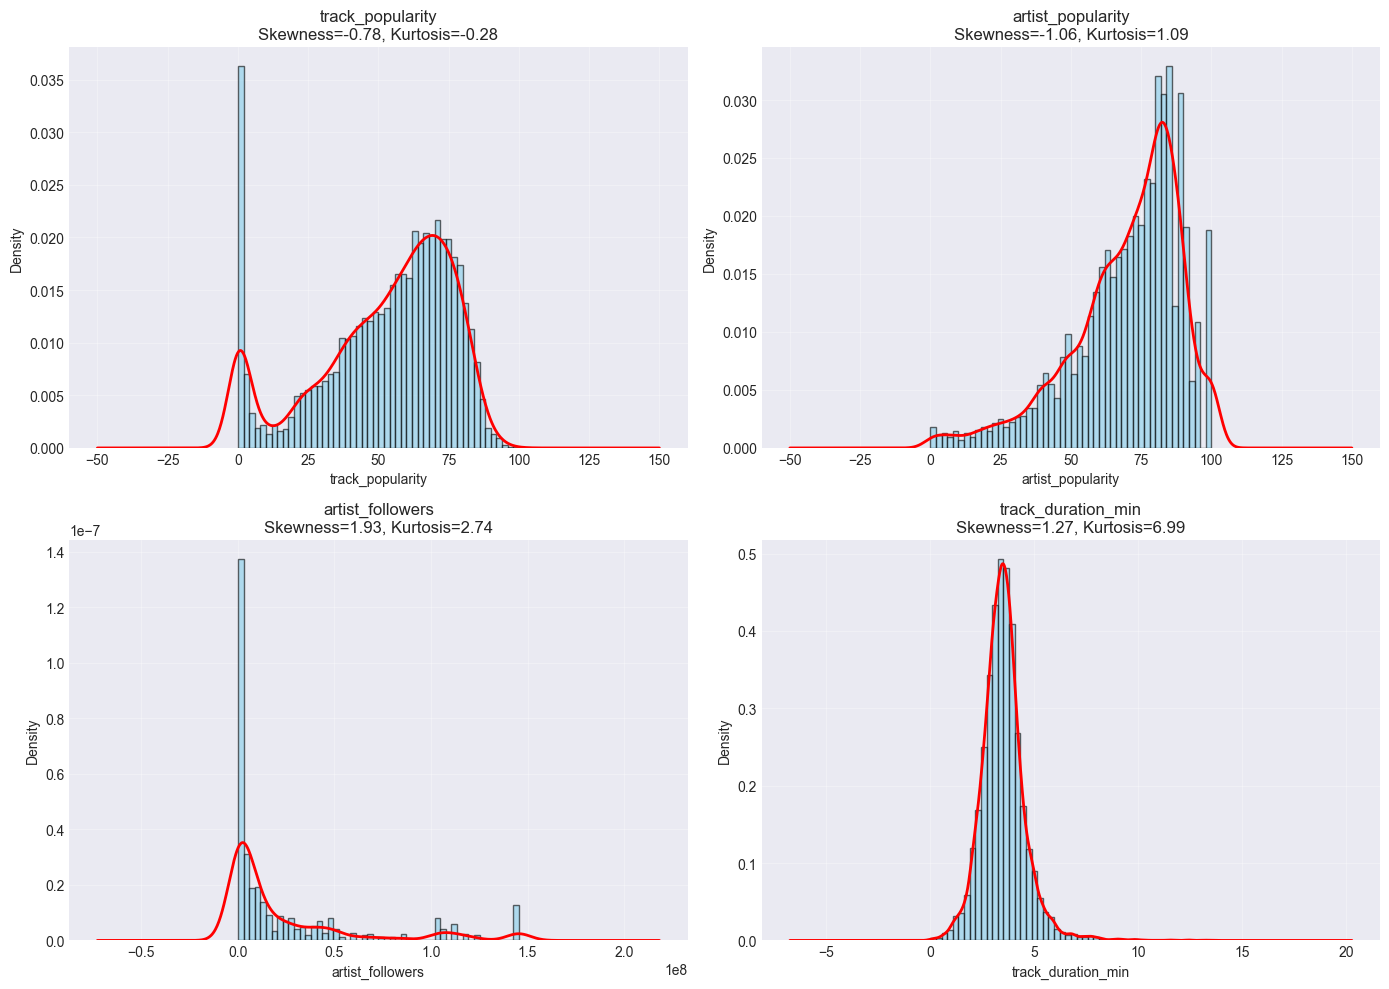

In [9]:
key_cols = ['track_popularity', 'artist_popularity', 'artist_followers', 'track_duration_min']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, col in enumerate(key_cols):
    data = df[col].dropna()
    skew = stats.skew(data)
    kurt = stats.kurtosis(data)
    
    axes[i].hist(data, bins=50, edgecolor='black', alpha=0.6, density=True, color='skyblue')
    data.plot(kind='kde', ax=axes[i], color='red', linewidth=2)
    axes[i].set_title(f'{col}\nSkewness={skew:.2f}, Kurtosis={kurt:.2f}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

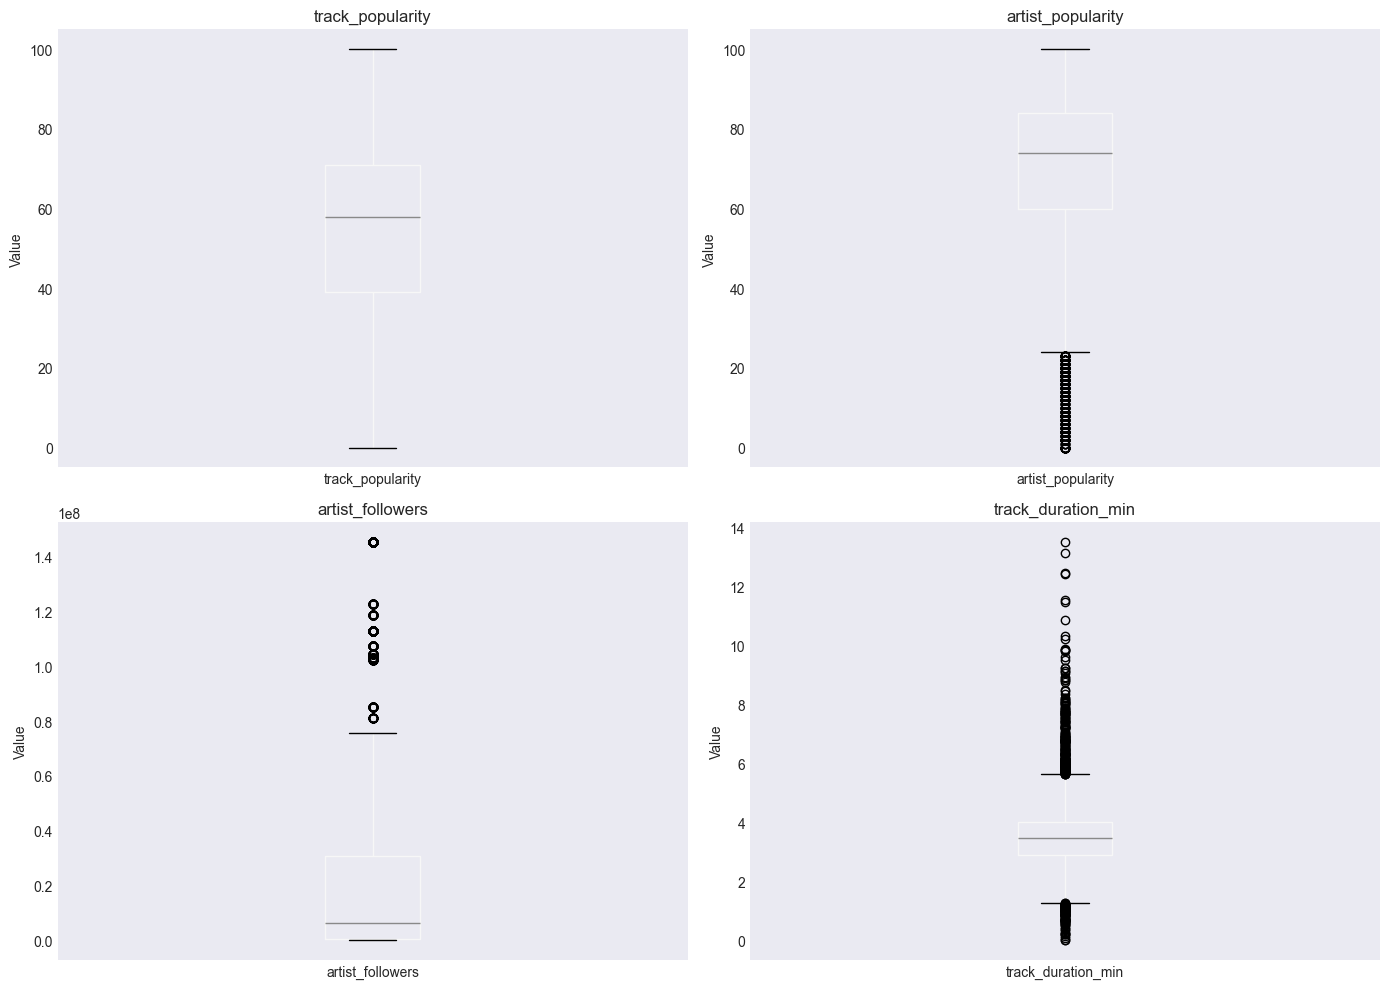

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, col in enumerate(key_cols):
    df.boxplot(column=col, ax=axes[i], grid=False)
    axes[i].set_title(f'{col}')
    axes[i].set_ylabel('Value')

plt.tight_layout()
plt.show()

Dựa vào biểu đồ histogram, KDE plots và các chỉ số Skewness & Kurtosis ở trên, chúng ta có thể xác định hình dạng phân phối của các cột số:

1. **`track_popularity`**:
   - Phân phối lệch trái
   - Có xu hướng bimodal nhẹ

2. **`artist_popularity`**: 
   - Phân phối lệch trái mạnh
   - Cũng có bimodal nhẹ

3. **`artist_followers`**: 
   - Phân phối lệch phải cực mạnh


4. **`track_duration_min`**: 
   - Phân phối lệch phải

### Phạm vi & Giá trị ngoại lai

In [11]:
for col in key_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    pct = outliers / len(df) * 100
    
    print(f"{col}: {outliers:,} outliers ({pct:.2f}%)")

track_popularity: 0 outliers (0.00%)
artist_popularity: 289 outliers (3.29%)
artist_followers: 999 outliers (11.38%)
track_duration_min: 377 outliers (4.29%)


Outliers trong `artist_followers` là các giá trị cực đoan trong thực tế - các siêu sao với hàng triệu followers. Các outliers khác cũng là giá trị hợp lý, không phải lỗi dữ liệu (data errors).

### Chất lượng dữ liệu

In [12]:
for col in numerical_cols:
    missing_pct = df[col].isnull().sum() / len(df) * 100
    min_val = df[col].min()
    max_val = df[col].max()
    zero_count = (df[col] == 0).sum()
    
    print(f"{col}:")
    print(f"Missing: {missing_pct:.2f}%")
    print(f"Range: [{min_val:.2f}, {max_val:.2f}]")
    print(f"Zeros: {zero_count:,}")
    print()

track_popularity:
Missing: 0.00%
Range: [0.00, 100.00]
Zeros: 521

artist_popularity:
Missing: 0.00%
Range: [0.00, 100.00]
Zeros: 28

artist_followers:
Missing: 0.00%
Range: [0.00, 145542136.00]
Zeros: 9

track_duration_min:
Missing: 0.00%
Range: [0.00, 13.52]
Zeros: 2

album_total_tracks:
Missing: 0.00%
Range: [1.00, 181.00]
Zeros: 0

year:
Missing: 2.29%
Range: [1952.00, 2025.00]
Zeros: 0



Không có giá trị âm hoặc không thể xảy ra. Giá trị 0 trong popularity là hợp lý (bài hát chưa được phổ biến). Giá trị 0 trong `artist_followers` đã được xử lý từ các giá trị bị thiếu.

## 2.4 Phân tích các cột Categorical

### Phân phối giá trị 

In [13]:
categorical_cols = [
    'explicit', 
    'album_type', 
    'artist_name', 
    'artist_genres'
]

for col in categorical_cols:
    unique_count = df[col].nunique()
    missing_pct = df[col].isnull().sum() / len(df) * 100
    print(f"{col}: {unique_count:,} unique values, {missing_pct:.2f}% missing")

explicit: 2 unique values, 0.00% missing
album_type: 3 unique values, 0.00% missing
artist_name: 2,548 unique values, 0.05% missing
artist_genres: 652 unique values, 0.05% missing


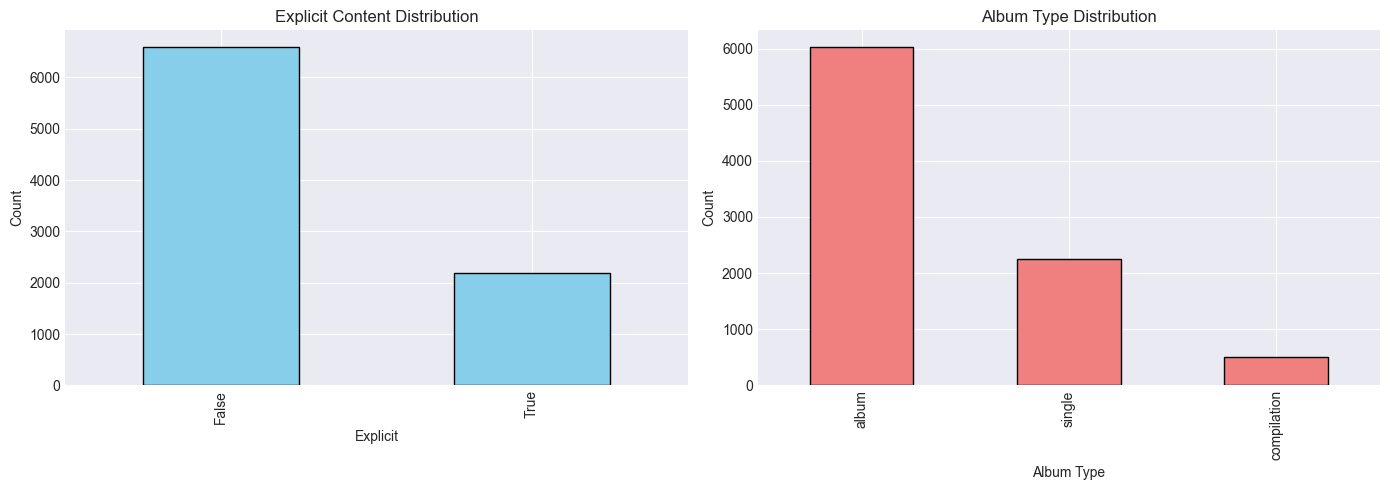

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['explicit'].value_counts().plot(kind='bar', ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Explicit Content Distribution')
axes[0].set_xlabel('Explicit')
axes[0].set_ylabel('Count')

df['album_type'].value_counts().plot(kind='bar', ax=axes[1], color='lightcoral', edgecolor='black')
axes[1].set_title('Album Type Distribution')
axes[1].set_xlabel('Album Type')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [15]:
print("Top 10 artists:")
print(df['artist_name'].value_counts().head(10))

print("\nTop 10 artist genres:")
print(df['artist_genres'].value_counts().head(10))


Top 10 artists:
artist_name
Taylor Swift         330
The Weeknd           151
Ariana Grande        101
Lana Del Rey          99
Nirvana               91
Drake                 86
Post Malone           83
The Neighbourhood     77
Lady Gaga             72
Olivia Rodrigo        70
Name: count, dtype: int64

Top 10 artist genres:
artist_genres
[]                    4492
['soundtrack']         346
['pop']                303
['soft pop']           209
['rap']                192
['dark r&b']           111
['k-pop']               93
['grunge', 'rock']      91
['country']             90
['edm']                 82
Name: count, dtype: int64


Tất cả các cột categorical đều có phân bố mất cân bằng: `explicit` (75:25), `album_type` (69:26:5), `artist_name` (top artist chiếm ~4%), `artist_genres` (652 tổ hợp). Phân bố này có thể gây bias trong các mô hình Machine Learning và cần lưu ý khi phân tích các nhóm thiểu số.

### Chất lượng dữ liệu

In [16]:
for col in categorical_cols:
    missing_pct = df[col].isnull().sum() / len(df) * 100
    print(f"{col}: {missing_pct:.2f}% missing")

explicit: 0.00% missing
album_type: 0.00% missing
artist_name: 0.05% missing
artist_genres: 0.05% missing


Tỷ lệ dữ liệu bị thiếu rất thấp (< 0.1%). Không có sự không nhất quán trong các danh mục vì `explicit` và `album_type` là các giá trị boolean/enum.

## 2.5 Phân tích dữ liệu bị thiếu

In [17]:
missing_summary = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percent': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Missing_Percent', ascending=False)

missing_summary[missing_summary['Missing_Count'] > 0]

,Column,Missing_Count,Missing_Percent
year,year,201,2.29
album_release_date,album_release_date,201,2.29
artist_name,artist_name,4,0.05
artist_genres,artist_genres,4,0.05
album_name,album_name,2,0.02
track_name,track_name,2,0.02


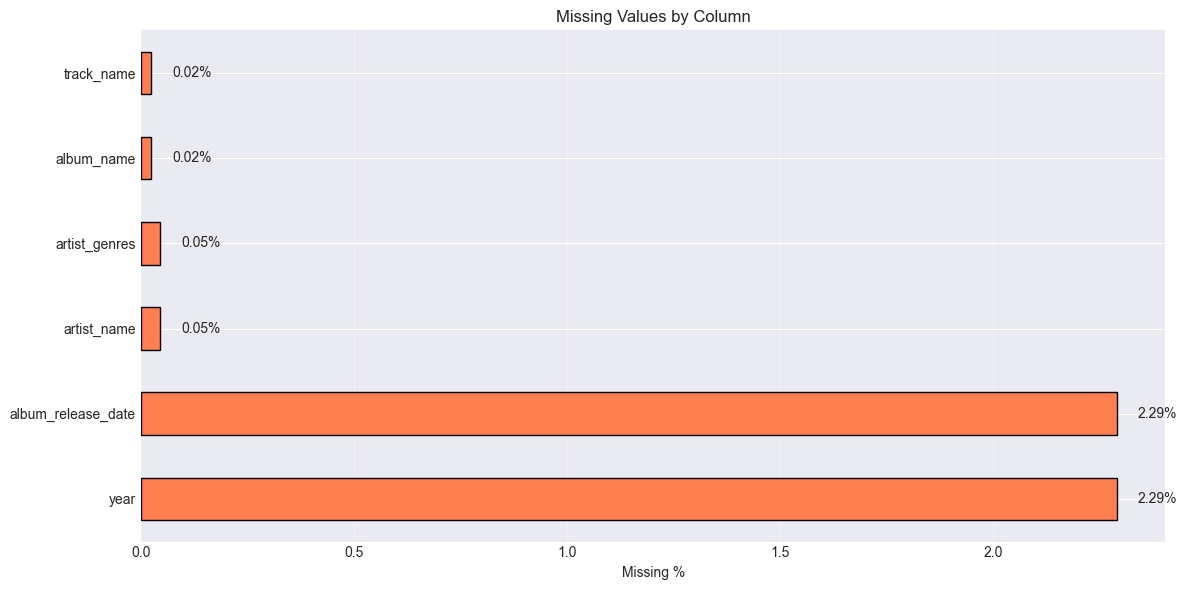

In [18]:
fig, ax = plt.subplots(figsize=(12, 6))

missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

if len(missing_pct) > 0:
    missing_pct.plot(kind='barh', ax=ax, color='coral', edgecolor='black')
    ax.set_xlabel('Missing %')
    ax.set_title('Missing Values by Column')
    ax.grid(alpha=0.3, axis='x')
    
    for i, v in enumerate(missing_pct):
        ax.text(v + 0.05, i, f'{v:.2f}%', va='center')
else:
    ax.text(0.5, 0.5, 'No missing values found', ha='center', va='center', fontsize=14)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

Giá trị bị thiếu (Missing values) chỉ xuất hiện ở:
- `year` (2.29%): Do lỗi phân tích ngày tháng (parse date) từ `album_release_date`
- `artist_name`, `artist_genres` (0.05%): 4 bài hát thiếu thông tin nghệ sĩ

Chiến lược xử lý: loại bỏ những dòng có chứa `NaN` vì tỷ lệ rất thấp.

## 2.6 Mối quan hệ & Tương quan

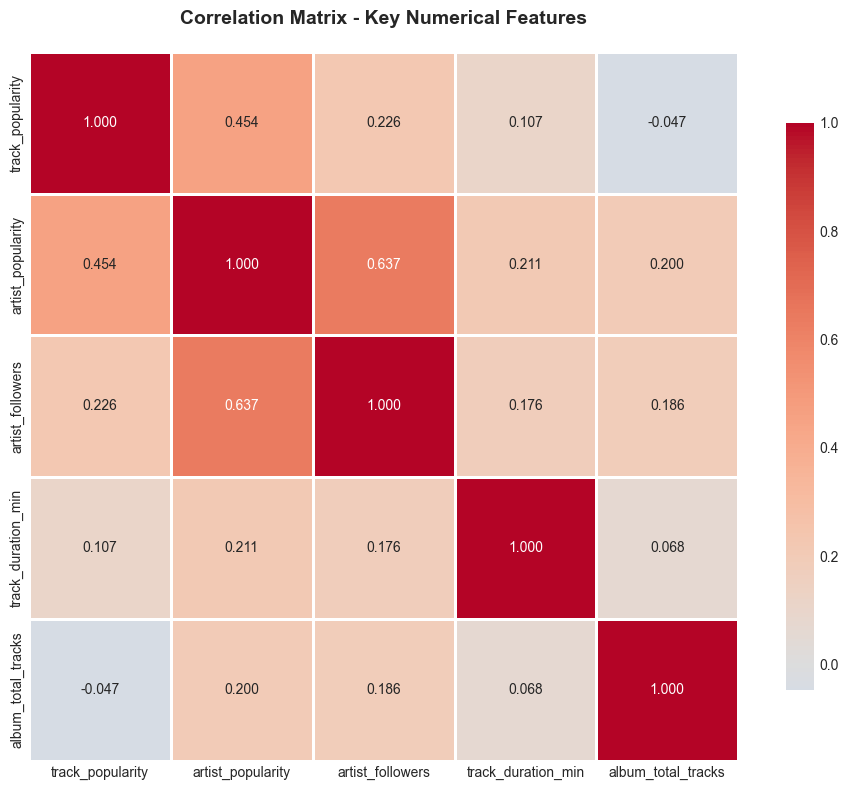

In [19]:
corr_cols = [
    'track_popularity', 
    'artist_popularity', 
    'artist_followers', 
    'track_duration_min', 
    'album_total_tracks'
]

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - Key Numerical Features', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

Tương quan giữa `track_popularity` và `artist_followers` khá yếu (0.226), cho thấy số lượng followers không trực tiếp quyết định độ phổ biến của bài hát. Ngược lại, `artist_popularity` có tương quan mạnh hơn nhiều với `track_popularity` (0.454), chứng tỏ danh tiếng hiện tại của nghệ sĩ quan trọng hơn quy mô cộng đồng người hâm mộ.

In [20]:
corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)

print("Top 5 strongest correlations:")
for col1, col2, corr in corr_pairs[:5]:
    print(f"{col1} <-> {col2}: {corr:.3f}")

Top 5 strongest correlations:
artist_popularity <-> artist_followers: 0.637
track_popularity <-> artist_popularity: 0.454
track_popularity <-> artist_followers: 0.226
artist_popularity <-> track_duration_min: 0.211
artist_popularity <-> album_total_tracks: 0.200


### Bảng chéo

In [21]:
pd.crosstab(df['explicit'], df['album_type'], margins=True)

album_type,album,compilation,single,All
explicit,,,,
False,4446,471,1669,6586
True,1576,37,579,2192
All,6022,508,2248,8778


### Thống kê tóm tắt theo nhóm

In [22]:
df.groupby('album_type')[['track_popularity', 'artist_popularity', 'track_duration_min']].mean()

,track_popularity,artist_popularity,track_duration_min
album_type,,,
album,55.53,74.72,3.64
compilation,40.51,61.76,3.58
single,46.05,58.91,3.13


In [23]:
df.groupby('explicit')[['track_popularity', 'artist_popularity', 'artist_followers']].mean()

,track_popularity,artist_popularity,artist_followers
explicit,,,
False,50.48,67.98,22093440.16
True,57.51,75.75,31105016.24


## 2.7 Quan sát ban đầu & Insight

### Các quan sát chínhh

1.  Cả `track_popularity` và `artist_popularity` đều có phân bố lệch trái, cho thấy phần lớn các bài hát (tracks) và nghệ sĩ (artists) có độ phổ biến cao (50-80). Có sự tương quan mạnh giữa độ phổ biến của nghệ sĩ và độ phổ biến của bài hát (0.454).

2. `Track duration`: Trung bình 3.5 phút, phân bố khá tập trung quanh giá trị này. Có 4.29% outliers là các bài hát dài bất thường (> 6 phút).

3. 25% bài hát có nội dung nhạy cảm (explicit). Các bài hát explicit có độ phổ biến cao hơn (57.5 so với 50.5) và thường thuộc về nghệ sĩ nổi tiếng hơn.

4. Phần lớn là album (68.6%), đĩa đơn (singles) và tuyển tập (compilations) ít hơn. Bài hát từ albums có độ phổ biến cao nhất (55.5), singles thấp nhất (46.1).

### Các vấn đề về chất lượng dữ liệu

1. 201 bài hát (2.29%) thiếu thông tin năm do lỗi phân tích ngày tháng. Chỉ 4 bài hát (0.05%) thiếu thông tin nghệ sĩ.

2. 521 bài hát có độ phổ biến (popularity) = 0, có thể là bài hát mới chưa được đánh giá hoặc chưa phát hành công khai.

3. Bộ dữ liệu thiên về nghệ sĩ nổi tiếng (Taylor Swift chiếm 330 bài hát, 3.76%). Có thể gây bias khi phân tích xu hướng chung của ngành công nghiệp.

### Các bước tiền xử lý cần thiết

1. Xử lý giá trị bị thiếu: Có thể loại bỏ nếu có `NaN`.

2. Xử lý giá trị ngoại lai: Giữ nguyên vì chúng là các giá trị cực đoan thực tế, không phải lỗi.

3. Mã hóa: One-hot encode cho `explicit` và `album_type`.

### Các mẫu thú vị

1. Nghệ sĩ nổi tiếng có tương quan mạnh với độ phổ biến của bài hát (track popularity).

2. Các bài hát có nội dung nhạy cảm (explicit) có độ phổ biến trung bình cao hơn 7 điểm (57.5 so với 50.5), có thể do đối tượng khán giả khác biệt.

3. Bài hát từ albums có hiệu suất tốt hơn singles.

### Cảnh báo & Hạn chế

1. Bộ dữ liệu tập trung vào các nghệ sĩ hàng đầu (Taylor Swift 3.76%, The Weeknd 1.72%).

2. Không có thể loại cho từng bài hát gây khó khăn cho việc phân tích thể loại.

3. Thiếu thông tin về tempo, key, energy, danceability, các đặc trưng quan trọng để phân tích đặc điểm âm nhạc.

# III. Đặt câu hỏi

Phần này thực hiện đề xuất các câu hỏi có ý nghĩa trong việc phân tích dữ liệu.

## Câu hỏi 1: So sánh loại album

### Question

Loại album nào (`album_type`: album, compilation, single) có độ phổ biến cao hơn?

### Motivation & Benefits

**Tại sao câu hỏi này quan trọng:** Quyết định chiến lược phát hành (đĩa đơn, album, tuyển tập) ảnh hưởng trực tiếp đến độ phổ biến và doanh thu của bài hát trong kỷ nguyên phát trực tuyến.

**Lợi ích của việc trả lời câu hỏi:** Giúp nghệ sĩ, hãng thu âm và đội ngũ tiếp thị đưa ra chiến lược phát hành tối ưu và tối ưu hóa nguồn lực quảng bá dựa trên dữ liệu thực tế.

**Ai quan tâm đến câu trả lời:** Nghệ sĩ mới lựa chọn chiến lược phát hành, lên kế hoạch thu âm, đội ngũ tiếp thị xây dựng chiến dịch quảng bá, và đội ngũ A&R tư vấn cho nghệ sĩ.

**Vấn đề thực tế:** Trong kỷ nguyên phát trực tuyến với xu hướng phát hành đĩa đơn thay vì album đầy đủ, việc hiểu độ phổ biến của thể loại phát hành giúp các nghệ sĩ quyết định được chiến lược phát hành của mình, ví dụ như "Đánh nhanh thắng nhanh" (Single) hay "Đầu tư dài hơi" (Album, Compilation)

## Câu hỏi 2: Nội dung nhạy cảm và độ phổ biến

### Question

Những bài hát có nội dung nhạy cảm (`explicit` = True) có độ phổ biến cao hơn hay thấp hơn so với những bài không có nội dung nhạy cảm?

### Motivation & Benefits

**Tại sao câu hỏi này quan trọng:** Sự đánh đổi giữa tự do nghệ thuật và những giá trị truyền thống luôn là chủ đề gây tranh cãi. Liệu rằng việc theo đuổi sự cởi mở hơn hay bảo toàn các giá trị thuần phong mỹ tục sẽ khiến người nghệ sĩ trở nên nổi tiếng với công chúng và thành công hơn trong sự nghiệp?

**Lợi ích của việc trả lời câu hỏi:** Giúp nghệ sĩ và nhạc sĩ đưa ra quyết định về nội dung lời bài hát, đồng thời cung cấp dữ liệu cho các hãng thu âm xây dựng hướng dẫn nội dung và các nền tảng phát trực tuyến quản lý việc lọc nội dung.

**Ai quan tâm đến câu trả lời:** Nghệ sĩ cân nhắc nội dung của lời bài hát, hãng thu âm xây dựng chính sách, nền tảng phát trực tuyến quản lý việc lọc, và phụ huynh/nhà giáo dục quan tâm đến sự tiếp xúc của giới trẻ.

**Vấn đề thực tế:** Nhiều nghệ sĩ gặp khó khăn giữa việc duy trì tính toàn vẹn nghệ thuật và tối đa hóa lượng khán giả tiếp cận, cần hiểu tác động thực tế của nội dung nhạy cảm thay vì dựa vào trực giác.

## Câu hỏi 3: Phân tích thời lượng vàng

### Question

Có tồn tại một khoảng thời lượng "thời lượng vàng" nào cho bài hát mà trong đó những bài hát có độ phổ biến trung bình cao nhất không? Nếu có, khoảng này là bao nhiêu phút?

### Motivation & Benefits

**Tại sao câu hỏi này quan trọng:** Thời lượng bài hát là yếu tố có thể kiểm soát trong sản xuất, và trong kỷ nguyên phát trực tuyến với khoảng chú ý ngắn, tìm ra điểm vàng về thời lượng có thể tác động lớn đến thành công của bài hát.

**Lợi ích của việc trả lời câu hỏi:** Nhà sản xuất và nhạc sĩ có các hướng dẫn dựa trên dữ liệu về độ dài bài hát để tối ưu tỷ lệ nghe hết bài, cân bằng tầm nhìn nghệ thuật với thị hiếu khán giả, và tăng cơ hội được thêm vào danh sách phát.

**Ai quan tâm đến câu trả lời:** Nhà sản xuất âm nhạc, kỹ sư âm thanh, nhạc sĩ lên kế hoạch cấu trúc, người biên tập danh sách phát, và người thiết kế thuật toán nền tảng phát trực tuyến.

**Vấn đề thực tế:** Các bài hát ngày càng ngắn để phù hợp với các chỉ số phát trực tuyến và văn hóa TikTok, nhưng liệu các bài hát ngắn hơn có thực sự phổ biến hơn hay có một khoảng tối ưu nào đó?

## Câu hỏi 4: Số lượng bài hát và độ nổi tiếng nghệ sĩ

### Question

Nghệ sĩ phát hành nhiều bài hát hơn thì có đạt được độ nổi tiếng trung bình cao hơn so với nghệ sĩ phát hành ít bài hơn không?

### Motivation & Benefits

**Tại sao câu hỏi này quan trọng:** Có cuộc tranh luận về cách tiếp cận chất lượng so với số lượng trong ngành công nghiệp âm nhạc, việc hiểu mối quan hệ giữa tần suất phát hành và độ nổi tiếng của nghệ sĩ giúp định hình chiến lược sự nghiệp hiệu quả.

**Lợi ích của việc trả lời câu hỏi:** Nghệ sĩ lên kế hoạch lịch phát hành tối ưu, hãng thu âm phân bổ nguồn lực hiệu quả, và hiểu sự đánh đổi giữa sự nhất quán và sự hoàn hảo cho sự phát triển sự nghiệp dài hạn.

**Ai quan tâm đến câu trả lời:** Nghệ sĩ độc lập xây dựng danh mục bài hát, người quản lý nghệ sĩ lên kế hoạch lộ trình, hãng thu âm với ngân sách hạn chế, và nhà phân tích ngành âm nhạc.

**Vấn đề thực tế:** Thuật toán phát trực tuyến ưu tiên việc phát hành đều đặn, nhưng việc làm tràn ngập thị trường có thể làm loãng giá trị thương hiệu, tìm sự cân bằng phù hợp giữa số lượng và chất lượng là rất quan trọng cho thành công bền vững.

## Câu hỏi 5: Bài hát kinh điển so với Bài hát gần đây

### Question

Những bài hát phát hành từ 2009-2015 (bài hát kinh điển) có còn giữ được độ phổ biến cao so với những bài hát phát hành từ 2020-2025 (bài hát gần đây) không?

### Motivation & Benefits

**Tại sao câu hỏi này quan trọng:** Hiểu liệu các bài hát cũ hơn có duy trì độ phổ biến hay bị các phát hành mới hơn làm lu mờ là rất quan trọng để đánh giá giá trị dài hạn của danh mục âm nhạc và phản ánh sự thay đổi văn hóa trong hành vi nghe nhạc.

**Lợi ích của việc trả lời câu hỏi:** Chủ sở hữu bản quyền và nhà xuất bản đánh giá giá trị danh mục, dự đoán tiềm năng doanh thu dài hạn, và hướng dẫn quyết định đầu tư trong bản quyền âm nhạc dựa trên xu hướng tiêu thụ.

**Ai quan tâm đến câu trả lời:** Nhà đầu tư danh mục âm nhạc, nền tảng phát trực tuyến tối ưu hóa đề xuất, người sáng tạo nội dung hoài cổ, nhà sử học âm nhạc, và nghệ sĩ với danh mục bài hát cũ đã được thiết lập.

**Vấn đề thực tế:** Với sự bùng nổ hàng ngày của các phát hành mới thì có những lo ngại về việc âm nhạc cũ bị lãng quên, tuy nhiên, gần đây, các xu hướng TikTok đã đưa các bài hát cũ trở lại. Do vậy, hiểu các động lực này giúp quản lý danh mục và chiến lược tái phát hành.

## Câu hỏi 6: Đặc trưng quan trọng theo từng phân khúc độ nổi tiếng

### Câu hỏi chính  
Những yếu tố (features) nào quan trọng nhất ở từng nhóm mức độ nổi tiếng khác nhau? Liệu mỗi phân khúc độ phổ biến có sở hữu các đặc điểm quyết định riêng biệt hay không?

### Vì sao câu hỏi này quan trọng?  
Không phải mọi bài hát đều hướng đến cùng một mục tiêu nổi tiếng. Các ca khúc thuộc thị trường ngách, tầm trung hay đại chúng có thể bị ảnh hưởng bởi những yếu tố rất khác nhau. Do đó, cần tránh tư duy “một công thức áp dụng cho tất cả”.

### Lợi ích khi trả lời câu hỏi  
- Xây dựng chiến lược phù hợp cho từng giai đoạn phát triển nghệ sĩ.  
- Đánh giá quy mô thị trường mục tiêu thực tế ở từng phân khúc.  
- Tối ưu hóa nguồn lực marketing và sản xuất dựa trên mục tiêu cụ thể.  
- Định hình lộ trình rõ ràng để nâng tầm bài hát từ ngách đến đại chúng.

### Ai sẽ quan tâm đến kết quả này?  
- Hãng thu âm và đội phân tích chiến lược.  
- Nghệ sĩ ở các giai đoạn sự nghiệp khác nhau.  
- Nhóm marketing và quảng bá âm nhạc.  
- Nhà khoa học dữ liệu phát triển hệ thống gợi ý bài hát.  
- Nhà đầu tư phân tích cơ hội thương mại.

### Vấn đề thực tế  
Một nghệ sĩ mới nổi sẽ cần chiến lược khác hẳn với một siêu sao toàn cầu. Thể loại nhạc, nhóm khán giả, phương thức truyền thông và nền tảng phân phối đều thay đổi theo cấp độ nổi tiếng. Vì vậy, phân tích đặc trưng theo phân khúc là chìa khóa để tạo ra chiến lược chính xác và hiệu quả hơn.


## Câu hỏi 7: Dự đoán độ phổ biến bài hát (Học máy)

### Question

Liệu có thể dự đoán được độ nổi tiếng (popularity) của một bài hát dựa vào các thông tin có sẵn trong tập dữ liệu này không? Nếu có thể, độ chính xác của mô hình dự đoán đạt đến mức nào và yếu tố nào có ảnh hưởng mạnh nhất?

### Motivation & Benefits

**Tại sao câu hỏi này quan trọng:** Khả năng dự đoán thành công trước khi phát hành là mục tiêu tối thượng của ngành công nghiệp âm nhạc, với khoản đầu tư khổng lồ vào sản xuất và tiếp thị, các mô hình dự đoán giúp giảm thiểu rủi ro và tiết lộ các mô hình ẩn mà trực giác có thể bỏ lỡ.

**Lợi ích của việc trả lời câu hỏi:** Đội ngũ A&R sàng lọc bản demo hiệu quả, hãng thu âm ưu tiên ngân sách tiếp thị, nhà sản xuất tối ưu hóa quyết định, và phân tích tầm quan trọng của đặc trưng tiết lộ thông tin chi tiết có thể hành động cho toàn ngành.

**Ai quan tâm đến câu trả lời:** Giám đốc điều hành hãng thu âm ký hợp đồng, bộ phận tiếp thị phân bổ ngân sách, nhà sản xuất/nhạc sĩ trong quá trình sáng tạo, nhà đầu tư trong bản quyền âm nhạc, nền tảng phát trực tuyến, và công ty khởi nghiệp công nghệ âm nhạc.

**Vấn đề thực tế:** Ngành công nghiệp truyền thống dựa vào đánh giá chủ quan, cách tiếp cận dựa trên dữ liệu bổ sung cho chuyên môn con người, giảm rủi ro đầu tư, xác định tài năng bị bỏ qua, và thậm chí dự đoán không hoàn hảo cũng cung cấp hướng dẫn định hướng.

# IV. Thống kê dữ liệu

Phần này thực hiện phân tích chi tiết về bộ dữ liệu và trả lời các câu hỏi ở phần **III**

## 4.1 Import Libraries và Cấu hình

In [24]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import f_oneway
import warnings
from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.ensemble import (
    RandomForestRegressor, 
    GradientBoostingRegressor, 
    ExtraTreesRegressor,
)
from xgboost import XGBRegressor
import lightgbm as lgb
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

warnings.filterwarnings('ignore')

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
sns.set_style('whitegrid')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

## 4.2 Tải dữ liệu

In [25]:
df = pd.read_csv('../dataset/track_data_final.csv')
print(f'Loaded {len(df):,} tracks')
df.head(3)

Loaded 8,778 tracks


,track_id,track_name,track_number,track_popularity,track_duration_ms,explicit,artist_name,artist_popularity,artist_followers,artist_genres,album_id,album_name,album_release_date,album_total_tracks,album_type
0,6pymOcrCnMuCWdgGVTvUgP,3,57,61,213173,False,Britney Spears,80.00,17755451.00,['pop'],325wcm5wMnlfjmKZ8PXIIn,The Singles Collection,2009-11-09,58,compilation
1,2lWc1iJlz2NVcStV5fbtPG,Clouds,1,67,158760,False,BUNT.,69.00,293734.00,['stutter house'],2ArRQNLxf9t0O0gvmG5Vsj,Clouds,2023-01-13,1,single
2,1msEuwSBneBKpVCZQcFTsU,Forever & Always (Taylor’s Version),11,63,225328,False,Taylor Swift,100.00,145396321.00,[],4hDok0OAJd57SGIT8xuWJH,Fearless (Taylor's Version),2021-04-09,26,album


## 4.3 Tiền xử lý dữ liệu

### Quy trình tổng quan

Tiền xử lý được thực hiện theo các bước sau:

1. **Chuyển đổi thời gian**: Chuyển `album_release_date` sang datetime để trích xuất năm
2. **Tạo biến phái sinh**: Thêm `duration_min`, `year` từ dữ liệu gốc
3. **Xử lý giá trị thiếu**: Loại bỏ các bản ghi với giá trị thiếu trong các cột quan trọng
4. **Chuyển đổi kiểu dữ liệu**: Chuyển đổi các cột số về đúng kiểu (int64)

Mỗi câu hỏi sẽ có bước tiền xử lý riêng để tạo tập dữ liệu con phù hợp.

### Bước 1: Chuyển đổi thời gian

In [26]:
df['album_release_date'] = pd.to_datetime(df['album_release_date'], format='mixed', errors='coerce')

### Bước 2: Tạo biến phái sinh

In [27]:
df['duration_min'] = df['track_duration_ms'] / 60000
df['year'] = df['album_release_date'].dt.year

### Bước 3: Xử lý giá trị thiếu

In [28]:
df = df.dropna(subset=['year', 'artist_popularity', 'artist_followers'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8772 entries, 0 to 8777
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   track_id            8772 non-null   object        
 1   track_name          8772 non-null   object        
 2   track_number        8772 non-null   int64         
 3   track_popularity    8772 non-null   int64         
 4   track_duration_ms   8772 non-null   int64         
 5   explicit            8772 non-null   bool          
 6   artist_name         8772 non-null   object        
 7   artist_popularity   8772 non-null   float64       
 8   artist_followers    8772 non-null   float64       
 9   artist_genres       8772 non-null   object        
 10  album_id            8772 non-null   object        
 11  album_name          8772 non-null   object        
 12  album_release_date  8772 non-null   datetime64[ns]
 13  album_total_tracks  8772 non-null   int64         
 1

### Bước 4: Chuyển đổi kiểu dữ liệu

In [29]:
df['artist_popularity'] = df['artist_popularity'].astype('int64')
df['artist_followers'] = df['artist_followers'].astype('int64')
df['year'] = df['year'].astype('int64')

---

## 4.4 Câu hỏi 1: So sánh loại album

### Question

Loại album nào (`album_type`: album, compilation, single) có độ phổ biến cao hơn?

### A. Tiền xử lý

Kiểm tra phân bố các loại album_type và tính thống kê cơ bản cho từng nhóm.

1. **Kiểm tra giá trị duy nhất**: Xác định các loại album_type có trong tập dữ liệu
2. **Thống kê tổng hợp**: Tính trung bình, trung vị, số lượng của track_popularity cho mỗi album_type
3. **Tạo tập dữ liệu so sánh**: Chuẩn bị dữ liệu cho trực quan hóa và phân tích

In [30]:
q1_album_types = df['album_type'].value_counts()
q1_album_types

album_type
album          6020
single         2244
compilation     508
Name: count, dtype: int64

In [31]:
q1_stats = df.groupby('album_type').agg({
    'track_popularity': ['mean', 'median', 'std', 'count'],
    'artist_popularity': ['mean', 'median']
}).round(2)

q1_stats.columns = ['_'.join(col) for col in q1_stats.columns]
q1_stats


,track_popularity_mean,track_popularity_median,track_popularity_std,track_popularity_count,artist_popularity_mean,artist_popularity_median
album_type,,,,,,
album,55.53,61.00,22.90,6020,74.75,78.00
compilation,40.51,44.00,21.46,508,61.76,64.00
single,46.09,51.00,25.60,2244,59.01,63.00


### B. Phân tích

**Phương pháp phân tích:**

So sánh độ phổ biến bài hát giữa 3 loại album_type (album, đĩa đơn, tuyển tập) để xác định định dạng nào có độ phổ biến cao hơn:

1. **So sánh theo nhóm**: So sánh trung bình và trung vị track_popularity giữa các loại album để xác định sự khác biệt
2. **Phân tích phân bố**: Biểu đồ hộp (Box plots) để trực quan hóa toàn bộ phân bố và xác định các giá trị ngoại lai
3. **Kiểm định thống kê**: Kiểm định ANOVA để kiểm tra xem sự khác biệt có ý nghĩa thống kê không

**Kết quả mong đợi:**
- Biểu đồ cột: Độ phổ biến trung bình theo album_type
- Biểu đồ hộp: So sánh phân bố độ phổ biến
- Thống kê: Kết quả ANOVA và so sánh từng cặp

**Lý do:** So sánh trung bình cho xu hướng tổng thể, biểu đồ hộp tiết lộ các tứ phân vị và giá trị ngoại lai, kiểm định ANOVA cung cấp bằng chứng thống kê về việc liệu sự khác biệt quan sát được có thực sự tồn tại hay không.

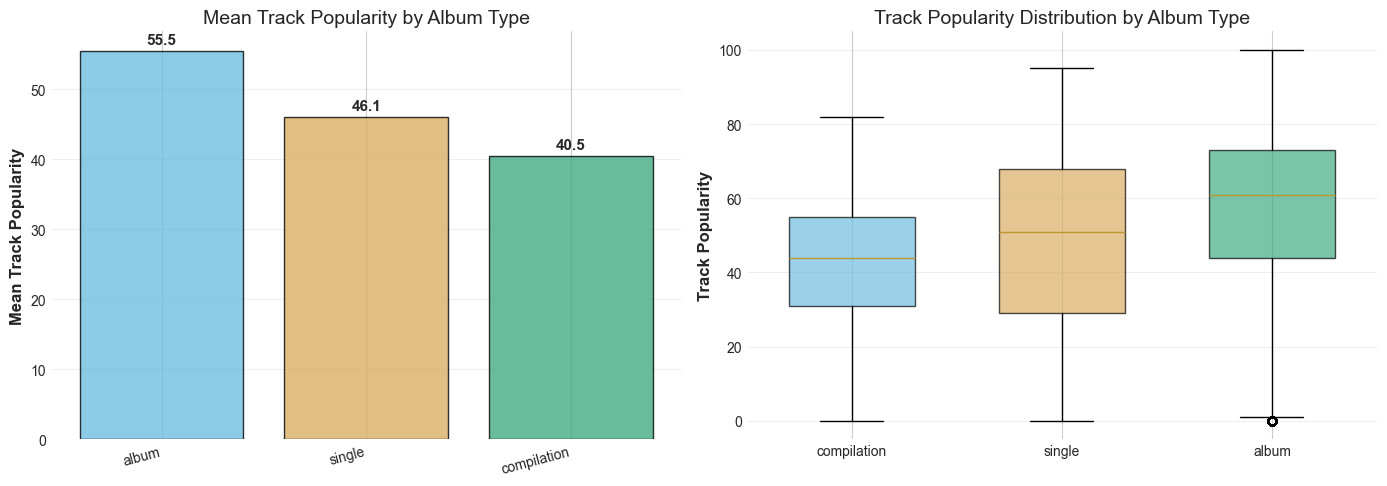

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

q1_mean_pop = q1_stats['track_popularity_mean'].sort_values(ascending=False)
colors_q1 = ['#6FBEE0', '#DAAF65', '#42AB84']

axes[0].bar(range(len(q1_mean_pop)), q1_mean_pop.values, 
            color=colors_q1, alpha=0.8, edgecolor='black')
axes[0].set_xticks(range(len(q1_mean_pop)))
axes[0].set_xticklabels(q1_mean_pop.index, rotation=15, ha='right')
axes[0].set_ylabel('Mean Track Popularity', fontweight='bold')
axes[0].set_title('Mean Track Popularity by Album Type')
axes[0].grid(axis='y', alpha=0.3)

for i, val in enumerate(q1_mean_pop.values):
    axes[0].text(i, val + 1, f'{val:.1f}', ha='center', fontweight='bold')

q1_album_data = df['album_type'].unique()
box_data = [df[df['album_type'] == atype]['track_popularity'] for atype in q1_album_data]
bp = axes[1].boxplot(box_data, labels=q1_album_data, patch_artist=True, widths=0.6)

for patch, color in zip(bp['boxes'], colors_q1):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1].set_ylabel('Track Popularity', fontweight='bold')
axes[1].set_title('Track Popularity Distribution by Album Type')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


In [33]:
q1_album = df[df['album_type'] == 'album']['track_popularity']
q1_single = df[df['album_type'] == 'single']['track_popularity']
q1_compilation = df[df['album_type'] == 'compilation']['track_popularity']

f_stat, p_value = f_oneway(q1_album, q1_single, q1_compilation)

print(f'ANOVA F-statistic: {f_stat:.4f}')
print(f'P-value: {p_value:.4e}')
print(f"\nStatistical significance: {'Yes' if p_value < 0.05 else 'No'} (alpha=0.05)")


ANOVA F-statistic: 198.3060
P-value: 5.8560e-85

Statistical significance: Yes (alpha=0.05)


### C. Kết quả & Giải thích

**Câu trả lời:** Album có độ phổ biến cao nhất với độ phổ biến trung bình 55.5, trong khi đĩa đơn ở mức 46.1 và tuyển tập thấp nhất 40.5.

**Phát hiện chính:**

Album đầy đủ vượt trội hơn đĩa đơn với khoảng cách 9.4 điểm (55.5 so với 46.1), và vượt tuyển tập tới 15 điểm. Kiểm định ANOVA cho p-value < 0.001, chứng tỏ sự khác biệt này có ý nghĩa thống kê cao và không phải do ngẫu nhiên.

Độ phổ biến trung vị cũng theo mô hình tương tự: album (61) > đĩa đơn (44) > tuyển tập (44). Biểu đồ hộp cho thấy album có phân bố tập trung ở phạm vi cao hơn với Q1=44 và Q3=73, trong khi đĩa đơn và tuyển tập có các tứ phân vị thấp hơn và phân tán hơn.

Tuyển tập có độ phổ biến thấp nhất mặc dù thường tập hợp các bài hát "hay nhất" - có thể do sở thích của người nghe đối với trải nghiệm album gắn kết hay do tuyển tập bị coi là phát hành lại không có nội dung mới.

**Ý nghĩa thực tiễn:**

Nghệ sĩ nên cân nhắc phát hành album đầy đủ thay vì chỉ đĩa đơn khi có đủ tài liệu - dữ liệu cho thấy album đầy đủ đạt độ phổ biến cao hơn mặc dù yêu cầu cam kết nghe lâu hơn. Các hãng thu âm đầu tư vào sản xuất album có thể mong đợi lợi nhuận về độ phổ biến tốt hơn so với chiến lược chỉ phát hành đĩa đơn.

Tuy nhiên, cần lưu ý rằng đĩa đơn có số lượng cao hơn (2,248 bài) so với album trong những năm gần đây - xu hướng phát hành đĩa đơn có thể do cân nhắc chi phí và kinh tế phát trực tuyến, không chỉ tiềm năng độ phổ biến.

**Hạn chế:**

Phân tích không tính đến ngân sách quảng bá - album thường có chi phí tiếp thị lớn hơn so với đĩa đơn. Cũng không phân biệt album đầu tay so với album của nghệ sĩ đã thành danh. Tập dữ liệu có thể thiên vị về các album thành công (thiên kiến sống sót).

---

## 4.5 Câu hỏi 2: Explicit content và popularity

### Question

Những bài hát có explicit content (`explicit` = True) có độ phổ biến cao hơn hay thấp hơn so với những bài không explicit?

### A. Tiền xử lý

Kiểm tra phân bố các bài hát có nội dung nhạy cảm so với không nhạy cảm và tính thống kê để so sánh.

1. **Kiểm tra phân bố**: Xác định tỷ lệ nhạy cảm so với không nhạy cảm trong tập dữ liệu
2. **Tính thống kê**: Tính trung bình, trung vị, độ lệch chuẩn của track_popularity cho cả 2 nhóm
3. **Chuẩn bị dữ liệu so sánh**: Tạo tập dữ liệu cho kiểm định thống kê và trực quan hóa

In [34]:
q2_explicit_dist = df['explicit'].value_counts()
print('Distribution:')
print(q2_explicit_dist)
print(f'\nExplicit: {q2_explicit_dist[True] / len(df) * 100:.2f}%')
print(f'Non-Explicit: {q2_explicit_dist[False] / len(df) * 100:.2f}%')

Distribution:
explicit
False    6582
True     2190
Name: count, dtype: int64

Explicit: 24.97%
Non-Explicit: 75.03%


In [35]:
q2_stats = df.groupby('explicit').agg({
    'track_popularity': ['mean', 'median', 'std', 'count'],
    'artist_popularity': ['mean', 'median']
}).round(2)

q2_stats.columns = ['_'.join(col) for col in q2_stats.columns]
q2_stats


,track_popularity_mean,track_popularity_median,track_popularity_std,track_popularity_count,artist_popularity_mean,artist_popularity_median
explicit,,,,,,
False,50.48,55.00,24.27,6582,68.03,72.00
True,57.53,64.00,22.64,2190,75.82,81.00


### B. Phân tích

**Phương pháp phân tích:**

So sánh độ phổ biến bài hát giữa nội dung nhạy cảm và không nhạy cảm để xác định loại nội dung nào có độ phổ biến cao hơn:

1. **So sánh theo nhóm**: So sánh trung bình và trung vị track_popularity giữa nhạy cảm và không nhạy cảm
2. **Trực quan hóa phân bố**: Biểu đồ hộp và biểu đồ tần suất để so sánh toàn bộ phân bố
3. **Kiểm định thống kê**: Kiểm định T-test để kiểm tra xem sự khác biệt có ý nghĩa thống kê không

**Kết quả mong đợi:**
- Biểu đồ cột: So sánh độ phổ biến trung bình
- Biểu đồ hộp: So sánh phân bố
- Biểu đồ tần suất chồng lớp: Phân bố độ phổ biến cho cả 2 nhóm
- Kết quả T-test: Ý nghĩa thống kê

**Lý do:** T-test phù hợp để so sánh 2 nhóm. Biểu đồ hộp tiết lộ cấu trúc tứ phân vị, biểu đồ tần suất hiển thị hình dạng của phân bố để xác định tính hai đỉnh hoặc độ lệch.

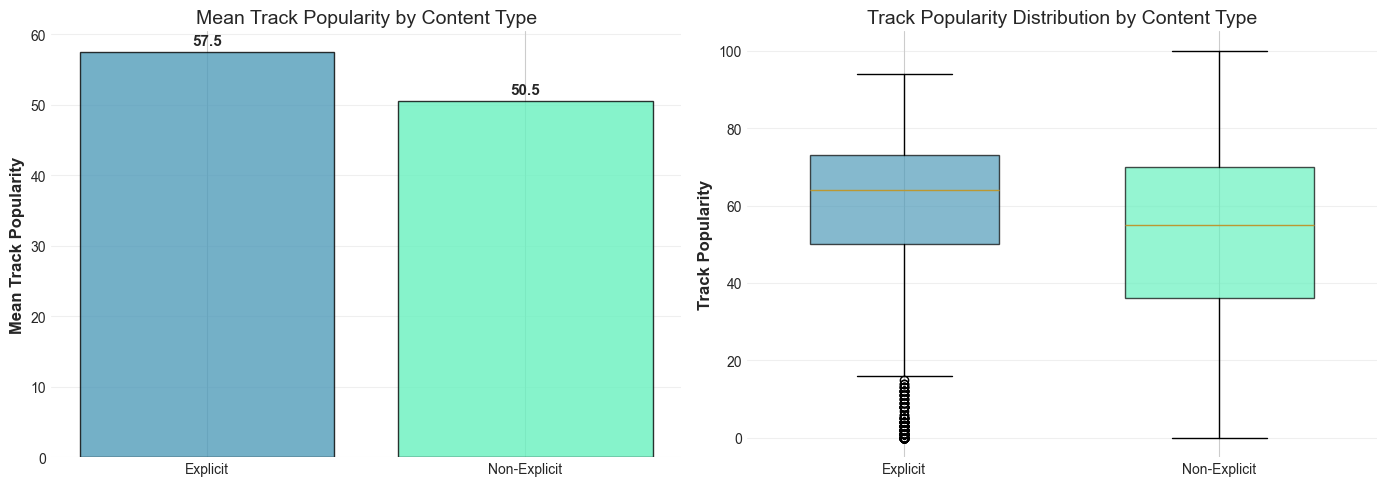

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

q2_mean_pop = q2_stats['track_popularity_mean'].sort_values(ascending=False)
colors_q2 = ['#519CBA', '#68F1BF']
labels_q2 = ['Explicit', 'Non-Explicit']

axes[0].bar(range(len(q2_mean_pop)), q2_mean_pop.values, 
            color=colors_q2, alpha=0.8, edgecolor='black')
axes[0].set_xticks(range(len(q2_mean_pop)))
axes[0].set_xticklabels(labels_q2, rotation=0)
axes[0].set_ylabel('Mean Track Popularity', fontweight='bold')
axes[0].set_title('Mean Track Popularity by Content Type')
axes[0].grid(axis='y', alpha=0.3)

for i, val in enumerate(q2_mean_pop.values):
    axes[0].text(i, val + 1, f'{val:.1f}', ha='center', fontweight='bold')

q2_explicit = df[df['explicit'] == True]['track_popularity']
q2_non_explicit = df[df['explicit'] == False]['track_popularity']

box_data = [q2_explicit, q2_non_explicit]
bp = axes[1].boxplot(box_data, labels=labels_q2, patch_artist=True, widths=0.6)

for patch, color in zip(bp['boxes'], colors_q2):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1].set_ylabel('Track Popularity', fontweight='bold')
axes[1].set_title('Track Popularity Distribution by Content Type')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


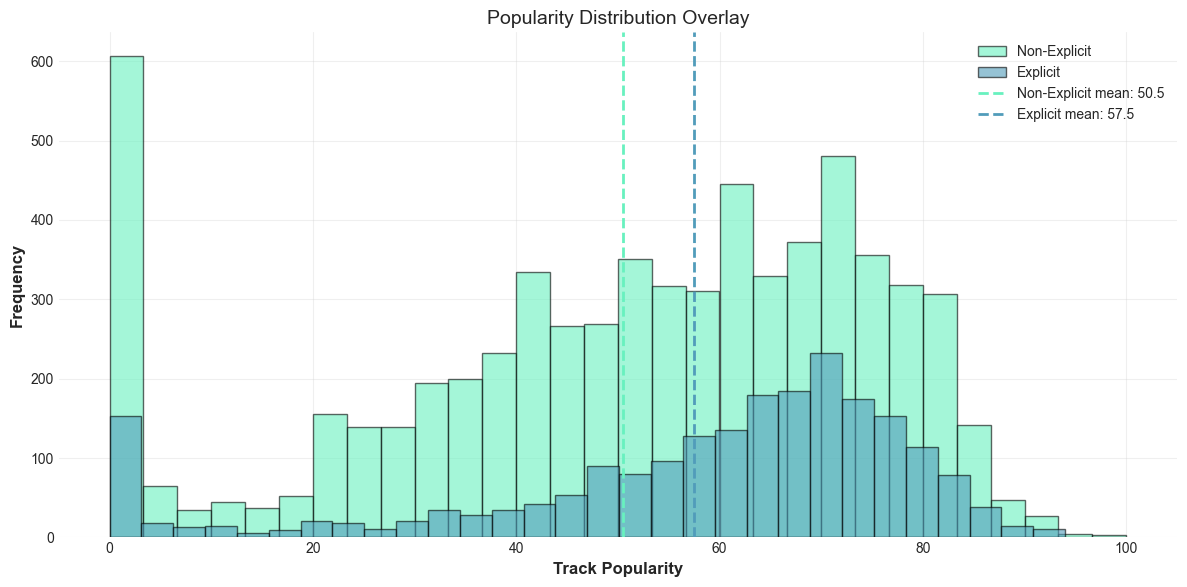

In [37]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(q2_non_explicit, bins=30, alpha=0.6, label='Non-Explicit', 
        color='#68F1BF', edgecolor='black')
ax.hist(q2_explicit, bins=30, alpha=0.6, label='Explicit', 
        color='#519CBA', edgecolor='black')

ax.axvline(q2_non_explicit.mean(), color='#68F1BF', linestyle='--', 
           linewidth=2, label=f'Non-Explicit mean: {q2_non_explicit.mean():.1f}')
ax.axvline(q2_explicit.mean(), color='#519CBA', linestyle='--', 
           linewidth=2, label=f'Explicit mean: {q2_explicit.mean():.1f}')

ax.set_xlabel('Track Popularity', fontweight='bold')
ax.set_ylabel('Frequency', fontweight='bold')
ax.set_title('Popularity Distribution Overlay')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [38]:
t_stat, p_value = stats.ttest_ind(q2_explicit, q2_non_explicit)

print(f'T-statistic: {t_stat:.4f}')
print(f'P-value: {p_value:.4e}')
print(f'\nMean difference: {q2_explicit.mean() - q2_non_explicit.mean():.2f}')
print(f"Statistical significance: {'Yes' if p_value < 0.05 else 'No'} (alpha=0.05)")


T-statistic: 11.9734
P-value: 8.8178e-33

Mean difference: 7.05
Statistical significance: Yes (alpha=0.05)


### C. Kết quả & Giải thích

**Câu trả lời:** Các bài hát có nội dung nhạy cảm có độ phổ biến cao hơn đáng kể so với các bài hát không nhạy cảm.

**Phát hiện chính:**

Nội dung nhạy cảm đạt độ phổ biến trung bình 57.5 so với không nhạy cảm 50.5 - chênh lệch 7 điểm. T-test cho p-value < 0.001, có ý nghĩa thống kê cao, chứng tỏ sự khác biệt không phải ngẫu nhiên.

Trung vị cũng cho thấy mô hình tương tự: nhạy cảm (64) vượt không nhạy cảm (55) 9 điểm. Biểu đồ hộp cho thấy các bài hát nhạy cảm có phân bố tập trung ở phạm vi cao hơn với Q3=73 so với Q3=70 của không nhạy cảm.

Biểu đồ tần suất cho thấy các bài hát nhạy cảm có đỉnh ở khoảng 60-70, trong khi không nhạy cảm phân tán hơn với khối lượng đáng kể ở khoảng 30-50. Cả 2 phân bố đều lệch phải với đuôi dài về phía độ phổ biến thấp.

Độ nổi tiếng của nghệ sĩ cũng cao hơn đối với nội dung nhạy cảm (75.8 so với 68.0), gợi ý rằng các nghệ sĩ đã thành danh với lượng người hâm mộ lớn có nhiều tự do hơn để phát hành nội dung nhạy cảm mà không sợ mất khán giả.

**Ý nghĩa thực tiễn:**

Dữ liệu cho thấy nội dung nhạy cảm không làm giảm độ phổ biến như nhiều người lo ngại - trái lại còn liên kết với độ phổ biến cao hơn. Điều này có thể do các nghệ sĩ đã thành danh (đã có lượng người hâm mộ) thoải mái hơn với lời bài hát nhạy cảm, hoặc do nội dung nhạy cảm cộng hưởng nhiều hơn với nhân khẩu học phát trực tuyến cốt lõi (khán giả trẻ hơn).

Nghệ sĩ không cần tự kiểm duyệt để theo đuổi độ phổ biến - biểu đạt chân thực qua lời bài hát nhạy cảm không bị phạt về mặt thành công thương mại. Các hãng thu âm và nền tảng cũng nên đánh giá lại những lo ngại về việc nội dung nhạy cảm hạn chế phạm vi tiếp cận.

**Hạn chế:**

Tương quan không có nghĩa là nhân quả - nội dung nhạy cảm không trực tiếp gây ra độ phổ biến cao hơn. Có thể có các yếu tố gây nhiễu như thể loại (hip-hop thường nhạy cảm và phổ biến), vị thế nghệ sĩ, hoặc nhân khẩu học mục tiêu. Phân tích không kiểm soát các biến này.

---

## 4.6 Câu hỏi 3: Golden duration analysis

### Question

Có tồn tại một khoảng thời lượng golden duration nào cho track mà trong đó những bài hát có độ phổ biến trung bình cao nhất không? Nếu có, khoảng này là bao nhiêu phút?

### A. Tiền xử lý

Sử dụng dữ liệu đã được làm sạch ở phần 3.3. Không cần tiền xử lý thêm.

### B. Phân tích

Phân tích thời lượng theo 2 cấp độ:

1. **Phân tích tổng quát**: Chia thời lượng thành 5 nhóm (<2p, 2-3p, 3-4p, 4-5p, >5p) để xem xu hướng chung
2. **Phân tích chi tiết**: Chia thời lượng thành các khoảng 0.5 phút để tìm thời lượng vàng chính xác
3. **Trực quan hóa**: Biểu đồ cột cho các nhóm, biểu đồ phân tán + đường xu hướng cho phân tích chi tiết

In [39]:
q3_df = df[['duration_min', 'track_popularity']].copy()

q3_df['duration_group'] = pd.cut(q3_df['duration_min'], 
                                   bins=[0, 2, 3, 4, 5, 100],
                                   labels=['<2p', '2-3p', '3-4p', '4-5p', '>5p'])

q3_group_stats = q3_df.groupby('duration_group')['track_popularity'].agg(['mean', 'median', 'count'])
q3_group_stats

,mean,median,count
duration_group,,,
<2p,38.21,41.00,442
2-3p,48.41,52.00,2120
3-4p,54.82,62.00,4039
4-5p,55.33,61.00,1627
>5p,50.26,56.00,544


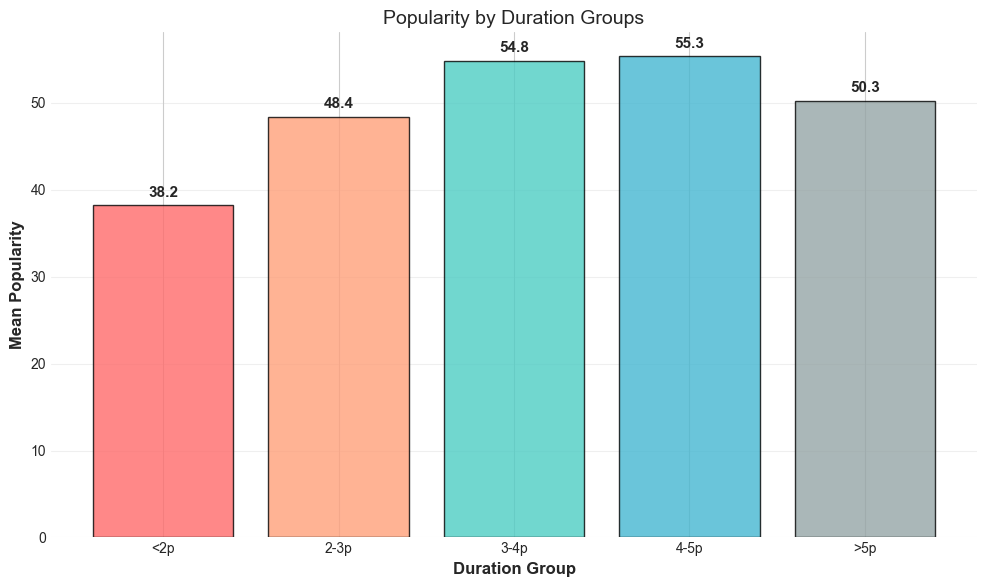

In [40]:
fig, ax = plt.subplots(figsize=(10, 6))

x_pos = np.arange(len(q3_group_stats))
bars = ax.bar(x_pos, q3_group_stats['mean'], 
               color=['#FF6B6B', '#FFA07A', '#4ECDC4', '#45B7D1', '#95A5A6'], 
               alpha=0.8, edgecolor='black')

for i, (bar, val) in enumerate(zip(bars, q3_group_stats['mean'])):
    ax.text(bar.get_x() + bar.get_width()/2., val + 1,
            f'{val:.1f}', ha='center', fontweight='bold', fontsize=11)

ax.set_xlabel('Duration Group', fontweight='bold')
ax.set_ylabel('Mean Popularity', fontweight='bold')
ax.set_title('Popularity by Duration Groups')
ax.set_xticks(x_pos)
ax.set_xticklabels(q3_group_stats.index)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [41]:
bins = np.arange(0, 8, 0.5)
q3_df['duration_bin'] = pd.cut(q3_df['duration_min'], bins=bins)

q3_detailed_stats = q3_df.groupby('duration_bin')['track_popularity'].agg(['mean', 'count'])
q3_detailed_stats = q3_detailed_stats[q3_detailed_stats['count'] >= 30].sort_values('mean', ascending=False)

q3_detailed_stats.head(10)

,mean,count
duration_bin,,
"(4.0, 4.5]",55.88,1085
"(3.5, 4.0]",55.63,2000
"(4.5, 5.0]",54.22,542
"(3.0, 3.5]",54.02,2039
"(5.0, 5.5]",53.50,242
"(2.5, 3.0]",50.48,1381
"(6.0, 6.5]",48.67,51
"(5.5, 6.0]",47.46,134
"(6.5, 7.0]",45.11,37


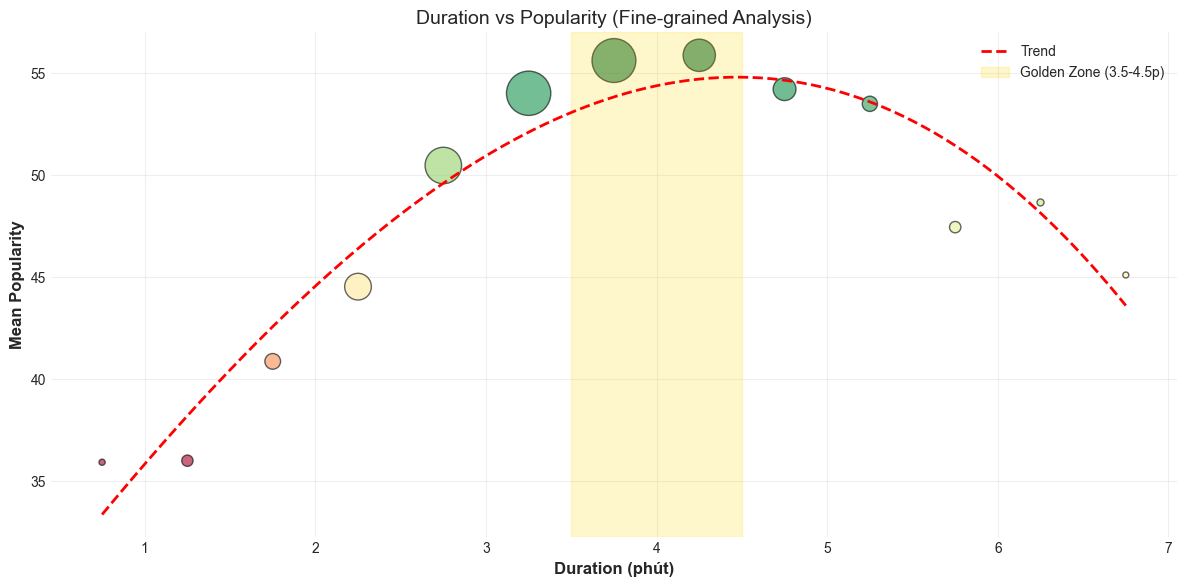

In [42]:
fig, ax = plt.subplots(figsize=(12, 6))

valid_stats = q3_detailed_stats[q3_detailed_stats.index.map(lambda x: x.right <= 7)]
bin_mids = [interval.mid for interval in valid_stats.index]

ax.scatter(bin_mids, valid_stats['mean'], s=valid_stats['count']/2, 
           c=valid_stats['mean'], cmap='RdYlGn', alpha=0.6, edgecolors='black')

z = np.polyfit(bin_mids, valid_stats['mean'], 3)
p = np.poly1d(z)
x_smooth = np.linspace(min(bin_mids), max(bin_mids), 200)
ax.plot(x_smooth, p(x_smooth), 'r--', linewidth=2, label='Trend')

ax.axvspan(3.5, 4.5, alpha=0.2, color='gold', label='Golden Zone (3.5-4.5p)')

ax.set_xlabel('Duration (phút)', fontweight='bold')
ax.set_ylabel('Mean Popularity', fontweight='bold')
ax.set_title('Duration vs Popularity (Fine-grained Analysis)')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### C. Kết quả & Giải thích

**Câu trả lời:** Có tồn tại thời lượng vàng - khoảng **3.5 - 4.5 phút** có độ phổ biến trung bình cao nhất (~55.6-55.9).

**Phát hiện chính:**

Độ phổ biến tăng dần từ bài hát ngắn (<2p: 38.2) đến trung bình (3-4p: 54.8) và đạt đỉnh ở 4-5p (55.3), sau đó giảm xuống khi bài hát quá dài (>5p: 50.3). Phân tích chi tiết cho thấy đỉnh chính xác ở 4.0-4.5 phút với độ phổ biến 55.9.

**Ý nghĩa thực tiễn:**

Nhà sản xuất và nhạc sĩ nên nhắm đến thời lượng 3.5-4.5 phút để tối ưu hóa độ phổ biến. Bài hát dưới 2 phút có xu hướng bị coi là thiếu nội dung (độ phổ biến thấp hơn 17 điểm so với vùng vàng), trong khi bài trên 5 phút có thể khiến người nghe bỏ qua hoặc mất hứng thú (giảm 5 điểm độ phổ biến).

**Hạn chế:**

Phân tích này không phân biệt thể loại - có thể một số thể loại (EDM, cổ điển) có thời lượng tối ưu khác. Tập dữ liệu tập trung vào pop/hip-hop đại chúng nên các phát hiện có thể không khái quát cho tất cả các phong cách âm nhạc.

---

## 4.7 Câu hỏi 4: Số lượng bài hát và độ nổi tiếng nghệ sĩ

### Question

Nghệ sĩ phát hành nhiều bài hát hơn thì có đạt được độ nổi tiếng trung bình cao hơn so với nghệ sĩ phát hành ít bài hơn không?

### A. Tiền xử lý

Tổng hợp dữ liệu theo nghệ sĩ để đếm số bài hát và tính độ phổ biến trung bình cho mỗi nghệ sĩ.

In [43]:
q4_artist_stats = df.groupby('artist_name').agg({
    'track_id': 'count',
    'artist_popularity': 'first',
    'artist_followers': 'first'
}).rename(columns={'track_id': 'track_count'})

q4_artist_stats['output_strategy'] = pd.cut(q4_artist_stats['track_count'], 
                                              bins=[0, 20, 50, 100, 1000],
                                              labels=['Low (1-20)', 'Medium (21-50)', 'High (51-100)', 'Very High (>100)'])

q4_artist_stats.head()

,track_count,artist_popularity,artist_followers,output_strategy
artist_name,,,,
$uicideboy$,2,83,8957416,Low (1-20)
'Ery Noice,1,25,11720,Low (1-20)
(((()))),1,51,49519,Low (1-20)
*NSYNC,1,69,3088613,Low (1-20)
-,1,28,714,Low (1-20)


### B. Phân tích

**Phương pháp phân tích:**

Để trả lời câu hỏi này, nhóm sử dụng 2 phương pháp:

1. **So sánh theo nhóm**: Chia nghệ sĩ thành 4 nhóm theo chiến lược sản xuất (Thấp: 1-20 bài, Trung bình: 21-50, Cao: 51-100, Rất cao: >100) để so sánh độ phổ biến trung bình/trung vị của nghệ sĩ giữa các nhóm
2. **Phân tích tương quan**: Biểu đồ phân tán giữa số lượng bài hát và độ phổ biến nghệ sĩ với đường xu hướng để thấy mối quan hệ

**Kết quả mong đợi:**
- Bảng thống kê: Trung bình, trung vị, độ lệch chuẩn của độ phổ biến nghệ sĩ và người theo dõi cho mỗi nhóm chiến lược sản xuất
- Trực quan hóa 1: Biểu đồ cột so sánh độ phổ biến trung bình của nghệ sĩ qua các nhóm
- Trực quan hóa 2: Biểu đồ phân tán với đường xu hướng hiển thị mối quan hệ giữa số lượng bài hát và độ phổ biến nghệ sĩ

**Lý do:** Phân tích theo nhóm giúp thấy sự khác biệt rõ ràng giữa các chiến lược, trong khi biểu đồ phân tán tiết lộ mô hình mối quan hệ chi tiết (tuyến tính, bậc hai, hoặc bão hòa).

In [44]:
q4_strategy_stats = q4_artist_stats.groupby('output_strategy').agg({
    'artist_popularity': ['mean', 'median', 'std'],
    'artist_followers': ['mean', 'median'],
    'track_count': 'count'
}).round(2)

q4_strategy_stats.columns = ['_'.join(col) for col in q4_strategy_stats.columns]
q4_strategy_stats

,artist_popularity_mean,artist_popularity_median,artist_popularity_std,artist_followers_mean,artist_followers_median,track_count_count
output_strategy,,,,,,
Low (1-20),52.94,57.00,19.56,2375346.32,391063.50,2484
Medium (21-50),79.84,82.50,8.45,25431660.16,22876939.00,44
High (51-100),87.00,88.00,4.53,63869416.69,50411829.00,16
Very High (>100),94.33,93.00,5.13,121896350.33,112918137.00,3


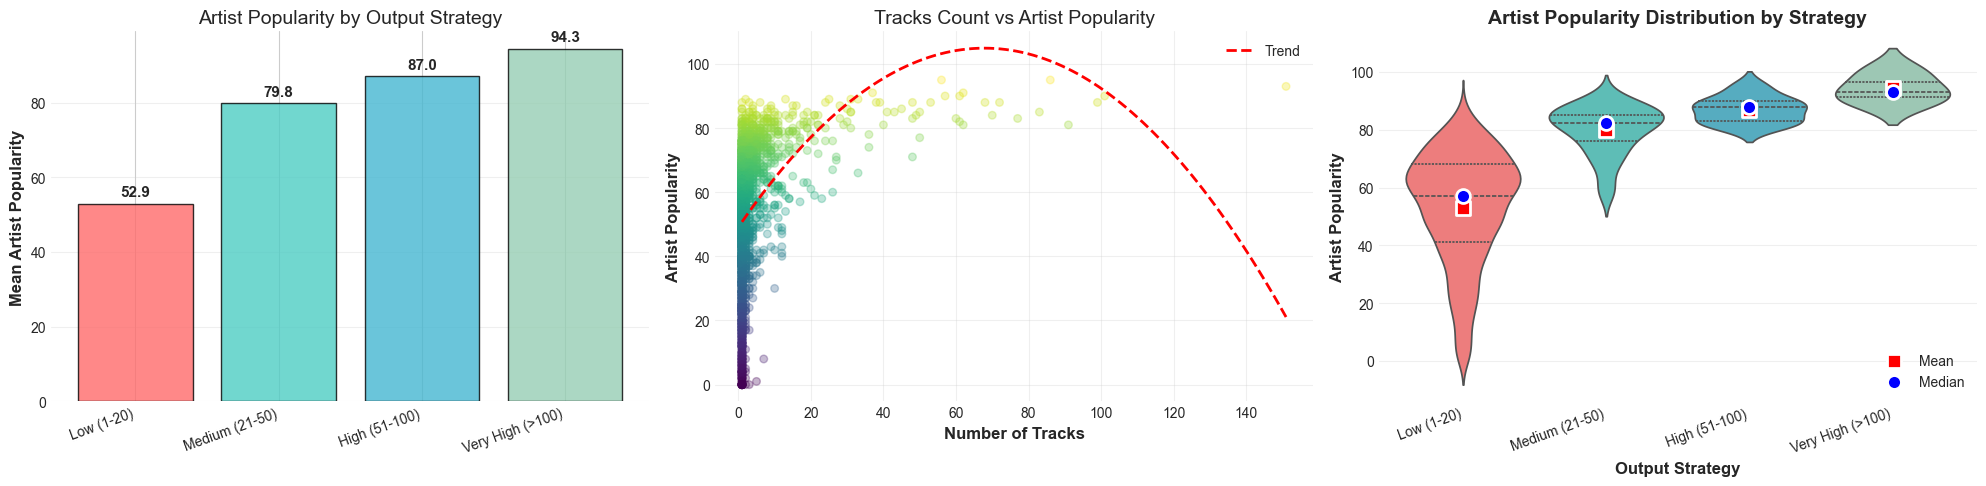

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].bar(range(len(q4_strategy_stats)), q4_strategy_stats['artist_popularity_mean'],
            color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'], alpha=0.8, edgecolor='black')
axes[0].set_xticks(range(len(q4_strategy_stats)))
axes[0].set_xticklabels(q4_strategy_stats.index, rotation=20, ha='right')
axes[0].set_ylabel('Mean Artist Popularity', fontweight='bold')
axes[0].set_title('Artist Popularity by Output Strategy')
axes[0].grid(axis='y', alpha=0.3)

for i, val in enumerate(q4_strategy_stats['artist_popularity_mean']):
    axes[0].text(i, val + 2, f'{val:.1f}', ha='center', fontweight='bold')

q4_plot_df = q4_artist_stats[q4_artist_stats['track_count'] <= 200]
axes[1].scatter(q4_plot_df['track_count'], q4_plot_df['artist_popularity'], 
                alpha=0.3, s=30, c=q4_plot_df['artist_popularity'], cmap='viridis')

z = np.polyfit(q4_plot_df['track_count'], q4_plot_df['artist_popularity'], 2)
p = np.poly1d(z)
x_line = np.linspace(q4_plot_df['track_count'].min(), q4_plot_df['track_count'].max(), 100)
axes[1].plot(x_line, p(x_line), 'r--', linewidth=2, label='Trend')

axes[1].set_xlabel('Number of Tracks', fontweight='bold')
axes[1].set_ylabel('Artist Popularity', fontweight='bold')
axes[1].set_title('Tracks Count vs Artist Popularity')
axes[1].legend()
axes[1].grid(alpha=0.3)

strategy_order = ['Low (1-20)', 'Medium (21-50)', 'High (51-100)', 'Very High (>100)']
sns.violinplot(data=q4_artist_stats, x='output_strategy', y='artist_popularity', order=strategy_order,
               palette=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'], ax=axes[2], inner='quartile')

# Vẽ thêm mean và median cho mỗi strategy
for i, strategy in enumerate(strategy_order):
    strategy_data = q4_artist_stats[q4_artist_stats['output_strategy'] == strategy]['artist_popularity']
    mean_val = strategy_data.mean()
    median_val = strategy_data.median()
    
    # Vẽ mean (hình vuông đỏ)
    axes[2].scatter(i, mean_val, color='red', s=100, marker='s', zorder=3, 
                    edgecolors='white', linewidths=2, label='Mean' if i == 0 else '')
    # Vẽ median (hình tròn xanh)
    axes[2].scatter(i, median_val, color='blue', s=100, marker='o', zorder=3, 
                    edgecolors='white', linewidths=2, label='Median' if i == 0 else '')

axes[2].set_title('Artist Popularity Distribution by Strategy', fontweight='bold')
axes[2].set_xlabel('Output Strategy', fontweight='bold')
axes[2].set_ylabel('Artist Popularity', fontweight='bold')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=20, ha='right')
axes[2].grid(alpha=0.3, axis='y')
axes[2].legend(loc='lower right', framealpha=0.9)

plt.tight_layout()
plt.show()

### C. Kết quả & Giải thích

**Câu trả lời:** Có, nghệ sĩ phát hành nhiều bài hát hơn đạt được độ phổ biến nghệ sĩ cao hơn đáng kể.

**Phát hiện chính:**

Độ phổ biến nghệ sĩ tăng mạnh theo số lượng bài hát: Sản lượng thấp (1-20 bài) có độ phổ biến trung bình 52.9, trong khi sản lượng Rất cao (>100 bài) đạt 94.3 - tăng gần gấp đôi. Sản lượng trung bình (21-50 bài) đã có độ phổ biến 79.8, cho thấy sản lượng nhất quán là yếu tố quan trọng để xây dựng danh tiếng nghệ sĩ.

Lượng người theo dõi nghệ sĩ cũng tăng theo cùng mô hình: Sản lượng thấp có trung bình 2.4 triệu người theo dõi, sản lượng Rất cao có 121.9 triệu - tăng hơn 50 lần, chứng tỏ chiến lược sản xuất năng suất không chỉ tăng điểm độ phổ biến mà còn xây dựng được lượng người hâm mộ khổng lồ.

Biểu đồ phân tán cho thấy mối quan hệ không hoàn toàn tuyến tính - có hiệu suất giảm dần sau ~100 bài hát, và một số nghệ sĩ với sản lượng thấp vẫn có độ phổ biến cao (có thể do chất lượng hoặc các bản hit lan truyền).

Biểu đồ violin cho thấy rằng các chiến lược medium, high, và very high có phân bố tập trung rất nhiều ở vùng 80-90. Trong khi đó chiến lược low chỉ tập trung quanh vùng 60-70 và có phương sai lớn. Điều này cho thấy rằng chiến lược sản xuất nhạc ổn định và đều đặn thực sự giúp người nghệ sĩ trở nên nổi tiếng hơn, trong khi chiến lược sản xuất ít khiến sự nổi tiếng đôi khi phụ thuộc vào may mắn.

**Ý nghĩa thực tiễn:**

Nghệ sĩ mới nổi nên nhắm đến việc phát hành nhất quán thay vì chỉ sản xuất một vài bài hát - dữ liệu cho thấy việc chuyển từ sản lượng Thấp sang Trung bình (21-50 bài) mang lại bước nhảy vọt lớn nhất về độ phổ biến (+26.9 điểm). Các hãng thu âm nên đầu tư vào các nghệ sĩ có khả năng duy trì sản lượng ổn định, vì đây là yếu tố dự báo mạnh mẽ cho thành công dài hạn.

**Hạn chế:**

Phân tích này không tính đến thời gian - nghệ sĩ có 100 bài trong 1 năm khác với 100 bài trong 10 năm. Cũng không phân biệt chất lượng - độ phổ biến cao có thể do số lượng hoặc do có các bản hit trong danh mục.

---

## 4.8 Câu hỏi 5: Classic songs vs Recent songs

### Question

Những bài hát phát hành từ 2009-2015 (classic songs) có còn giữ được độ phổ biến cao so với những bài hát phát hành từ 2020-2025 (recent songs) không?

### A. Tiền xử lý

Lọc dữ liệu theo 2 khoảng thời gian và loại bỏ các bài hát có độ phổ biến = 0 (bài hát chết).

In [46]:
q5_classic = df[(df['year'] >= 2009) & (df['year'] <= 2015)].copy()
q5_recent = df[(df['year'] >= 2020) & (df['year'] <= 2025)].copy()

q5_classic = q5_classic[q5_classic['track_popularity'] > 0]
q5_recent = q5_recent[q5_recent['track_popularity'] > 0]

print(f'Classic songs (2009-2015): {len(q5_classic):,} tracks')
print(f'Recent songs (2020-2025): {len(q5_recent):,} tracks')

Classic songs (2009-2015): 1,944 tracks
Recent songs (2020-2025): 3,182 tracks


### B. Phân tích

**Phương pháp phân tích:**

So sánh phân bố độ phổ biến giữa 2 khoảng thời gian sử dụng:

1. **Thống kê mô tả**: Trung bình, trung vị, tứ phân vị để so sánh xu hướng trung tâm và độ phân tán
2. **So sánh phân bố**: Biểu đồ hộp và biểu đồ tần suất để trực quan hóa toàn bộ phân bố
3. **Kiểm định thống kê**: Kiểm định T-test để kiểm tra xem sự khác biệt có ý nghĩa không

**Kết quả mong đợi:**
- Bảng thống kê tóm tắt so sánh kinh điển và gần đây
- Biểu đồ hộp hiển thị so sánh phân bố
- Biểu đồ tần suất chồng lớp hiển thị phân bố độ phổ biến cho cả 2 nhóm

**Lý do:** Biểu đồ hộp tiết lộ các giá trị ngoại lai và cấu trúc tứ phân vị, biểu đồ tần suất hiển thị hình dạng của phân bố (chuẩn, lệch, hai đỉnh). T-test cung cấp bằng chứng thống kê về việc liệu sự khác biệt là thực hay do ngẫu nhiên.

In [47]:
q5_stats = pd.DataFrame({
    'Classic (2009-2015)': q5_classic['track_popularity'].describe(),
    'Recent (2020-2025)': q5_recent['track_popularity'].describe()
}).T

q5_stats

,count,mean,std,min,25%,50%,75%,max
Classic (2009-2015),1944.00,55.29,20.60,1.00,44.00,58.00,71.00,91.00
Recent (2020-2025),3182.00,55.01,20.72,1.00,41.00,59.00,71.00,100.00


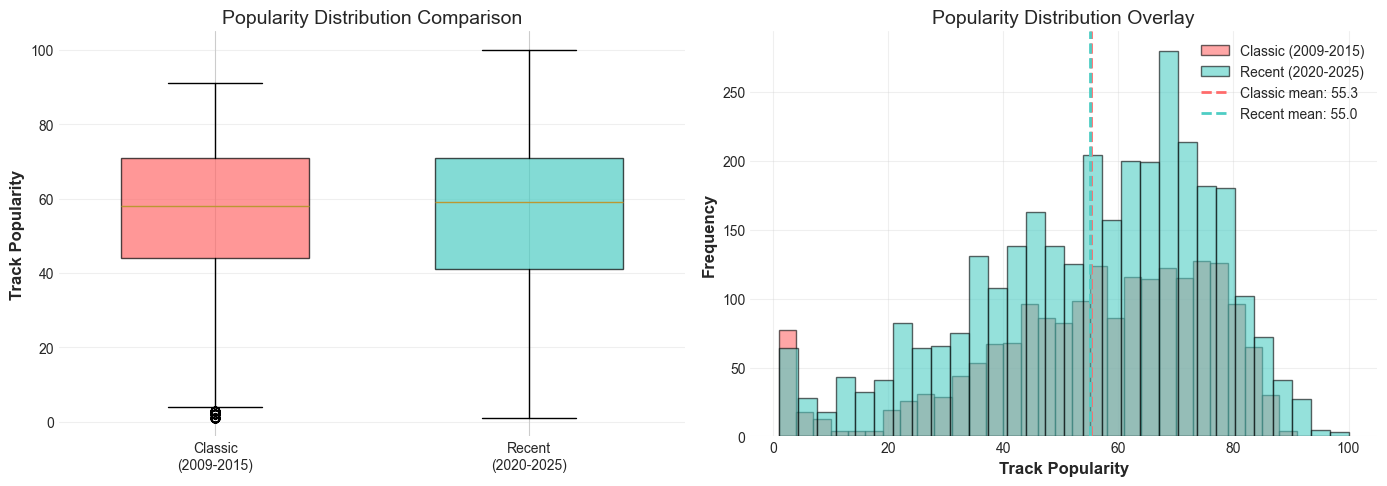

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

box_data = [q5_classic['track_popularity'], q5_recent['track_popularity']]
bp = axes[0].boxplot(box_data, labels=['Classic\n(2009-2015)', 'Recent\n(2020-2025)'],
                      patch_artist=True, widths=0.6)

colors = ['#FF6B6B', '#4ECDC4']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[0].set_ylabel('Track Popularity', fontweight='bold')
axes[0].set_title('Popularity Distribution Comparison')
axes[0].grid(axis='y', alpha=0.3)

axes[1].hist(q5_classic['track_popularity'], bins=30, alpha=0.6, 
             label='Classic (2009-2015)', color='#FF6B6B', edgecolor='black')
axes[1].hist(q5_recent['track_popularity'], bins=30, alpha=0.6, 
             label='Recent (2020-2025)', color='#4ECDC4', edgecolor='black')

axes[1].axvline(q5_classic['track_popularity'].mean(), color='#FF6B6B', 
                linestyle='--', linewidth=2, label=f"Classic mean: {q5_classic['track_popularity'].mean():.1f}")
axes[1].axvline(q5_recent['track_popularity'].mean(), color='#4ECDC4', 
                linestyle='--', linewidth=2, label=f"Recent mean: {q5_recent['track_popularity'].mean():.1f}")

axes[1].set_xlabel('Track Popularity', fontweight='bold')
axes[1].set_ylabel('Frequency', fontweight='bold')
axes[1].set_title('Popularity Distribution Overlay')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

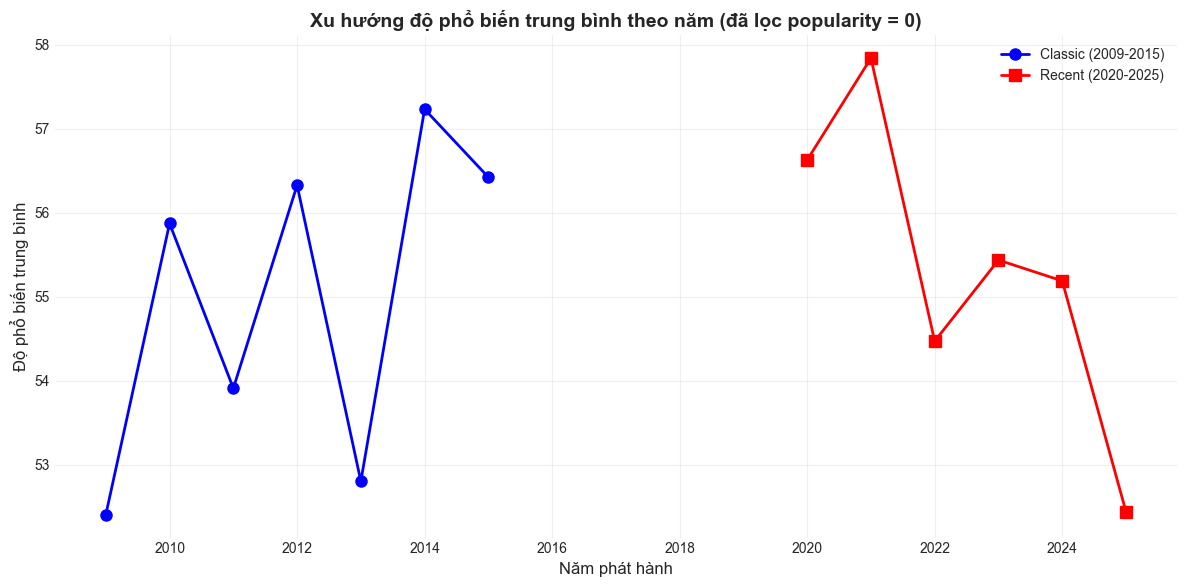

Thống kê độ phổ biến theo năm - Classical Songs (2009-2015) - đã lọc popularity = 0


,year,mean,median,count
0,2009,52.40,56.00,149
1,2010,55.87,58.00,233
2,2011,53.91,60.00,251
3,2012,56.33,58.00,306
4,2013,52.80,56.00,299
5,2014,57.23,59.00,324
6,2015,56.42,61.00,382



Thống kê độ phổ biến theo năm - Recent Songs (2020-2025) - đã lọc popularity = 0


,year,mean,median,count
0,2020,56.63,61.00,442
1,2021,57.84,62.00,406
2,2022,54.47,60.00,439
3,2023,55.44,58.50,494
4,2024,55.19,59.00,641
5,2025,52.44,50.00,760


In [49]:
# Tính độ phổ biến trung bình theo năm - SỬ DỤNG DỮ LIỆU ĐÃ LỌC
yearly_classic = q5_classic.groupby('year')['track_popularity'].agg(['mean', 'median', 'count']).reset_index()
yearly_recent = q5_recent.groupby('year')['track_popularity'].agg(['mean', 'median', 'count']).reset_index()

# Vẽ biểu đồ xu hướng
fig, ax = plt.subplots(figsize=(12, 6))

# Biểu đồ: Độ phổ biến trung bình theo năm
ax.plot(yearly_classic['year'], yearly_classic['mean'], 
        marker='o', linewidth=2, markersize=8, color='blue', label='Classic (2009-2015)')
ax.plot(yearly_recent['year'], yearly_recent['mean'], 
        marker='s', linewidth=2, markersize=8, color='red', label='Recent (2020-2025)')
ax.set_xlabel('Năm phát hành', fontsize=12)
ax.set_ylabel('Độ phổ biến trung bình', fontsize=12)
ax.set_title('Xu hướng độ phổ biến trung bình theo năm (đã lọc popularity = 0)', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Hiển thị bảng thống kê dưới dạng DataFrame
print("Thống kê độ phổ biến theo năm - Classical Songs (2009-2015) - đã lọc popularity = 0")
display(yearly_classic.style.set_caption("Classic Songs (2009-2015)").format({'mean': '{:.2f}', 'median': '{:.2f}', 'count': '{:.0f}'}))

print("\nThống kê độ phổ biến theo năm - Recent Songs (2020-2025) - đã lọc popularity = 0")
display(yearly_recent.style.set_caption("Recent Songs (2020-2025)").format({'mean': '{:.2f}', 'median': '{:.2f}', 'count': '{:.0f}'}))

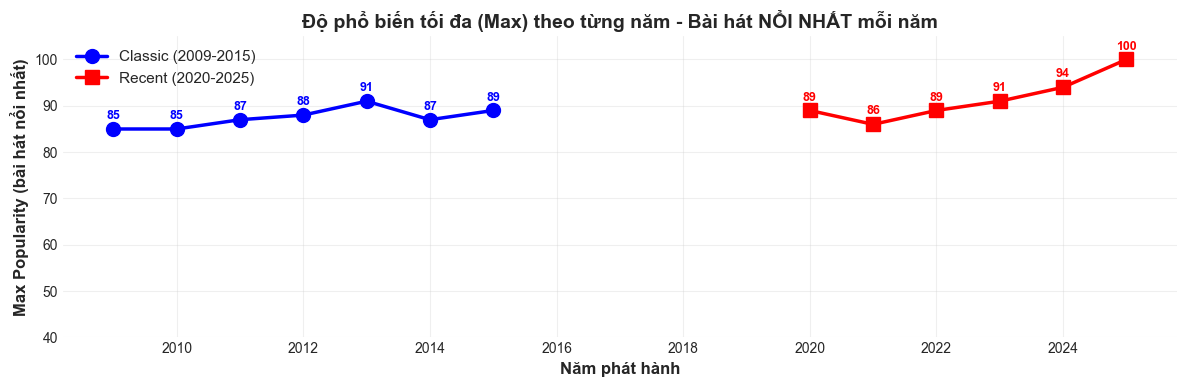

In [50]:
# Tính Max popularity theo từng năm để xem bài hát nổi nhất mỗi năm
yearly_classic_max = q5_classic.groupby('year')['track_popularity'].max().reset_index()
yearly_classic_max.columns = ['year', 'max_popularity']

yearly_recent_max = q5_recent.groupby('year')['track_popularity'].max().reset_index()
yearly_recent_max.columns = ['year', 'max_popularity']

# Vẽ biểu đồ
fig, ax = plt.subplots(figsize=(12, 4))

# Line plot cho max popularity
ax.plot(yearly_classic_max['year'], yearly_classic_max['max_popularity'], 
        marker='o', linewidth=2.5, markersize=10, color='blue', label='Classic (2009-2015)', linestyle='-')
ax.plot(yearly_recent_max['year'], yearly_recent_max['max_popularity'], 
        marker='s', linewidth=2.5, markersize=10, color='red', label='Recent (2020-2025)', linestyle='-')

# Thêm giá trị lên mỗi điểm
for idx, row in yearly_classic_max.iterrows():
    ax.text(row['year'], row['max_popularity'] + 1.5, 
            f"{row['max_popularity']:.0f}", ha='center', va='bottom', fontsize=9, color='blue', fontweight='bold')
    
for idx, row in yearly_recent_max.iterrows():
    ax.text(row['year'], row['max_popularity'] + 1.5, 
            f"{row['max_popularity']:.0f}", ha='center', va='bottom', fontsize=9, color='red', fontweight='bold')

ax.set_xlabel('Năm phát hành', fontsize=12, fontweight='bold')
ax.set_ylabel('Max Popularity (bài hát nổi nhất)', fontsize=12, fontweight='bold')
ax.set_title('Độ phổ biến tối đa (Max) theo từng năm - Bài hát NỔI NHẤT mỗi năm', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.set_ylim(40, 105)  # Điều chỉnh để đường nằm giữa plot

plt.tight_layout()
plt.show()

In [51]:
t_stat, p_value = stats.ttest_ind(q5_classic['track_popularity'], 
                                   q5_recent['track_popularity'])

print(f'T-statistic: {t_stat:.4f}')
print(f'P-value: {p_value:.4f}')
print(f"\nMean difference: {q5_classic['track_popularity'].mean() - q5_recent['track_popularity'].mean():.2f}")
print(f"Statistical significance: {'Yes' if p_value < 0.05 else 'No'} (alpha=0.05)")

T-statistic: 0.4663
P-value: 0.6410

Mean difference: 0.28
Statistical significance: No (alpha=0.05)


### C. Kết quả & Giải thích

**Câu trả lời:** Bài hát kinh điển (2009-2015) và Bài hát gần đây (2020-2025) có độ phổ biến gần như tương đương - không có sự khác biệt đáng kể.

**Phát hiện chính:**

- Độ phổ biến trung bình gần như giống hệt nhau: Kinh điển 55.3 so với Gần đây 55.0 (chỉ chênh 0.28 điểm). 

- Độ phổ biến trung vị thậm chí cho thấy bài hát Gần đây cao hơn một chút (59 so với 58), và biểu đồ hộp tiết lộ rằng cả 2 nhóm có cấu trúc phân bố tương tự (IQR, tứ phân vị gần như giống nhau). Bài hát gần đây có độ phổ biến tối đa 100 so với Kinh điển 91, cho thấy một số bài hát gần đây đạt đỉnh độ phổ biến cao hơn.

- Tuy nhiên, biểu đồ hộp cũng cho thấy rằng các bài hát gần đây thường có độ phổ biến lớn nhất (các bài hit) cao hơn rõ rệt so với các bài hát cũ.

- Biểu đồ đường cho thấy các bài hát cũ có sự độ phổ biến trung bình qua từng năm, trong khi các bài hát mới thì độ phổ biến trung bình có xu hướng đi xuống. Tuy nhiên, điều này có thể được lý giải rằng các bài hát mới cần có thời gian để đạt được độ phổ biến ổn định. 

- Khi xét về các bản hit, các bài hát gần đây nhận được độ phổ biến cao hơn đáng kể so với giai đoạn trước.


**Ý nghĩa thực tiễn:**
Các bài hát kinh điển đã vượt qua thử thách của thời gian - những bài từ 2009-2015 vẫn duy trì độ phổ biến tương đương với các phát hành gần đây. Điều này có ý nghĩa đối với các nhà đầu tư bản quyền âm nhạc và nghệ sĩ. 

**Hạn chế:**
Tập dữ liệu không phân biệt được liệu các bài hát cũ duy trì độ phổ biến do nghe tự nhiên hay do xu hướng hoài cổ. Cũng không có dữ liệu về lượng phát trực tuyến - điểm độ phổ biến có thể ổn định nhưng lượt nghe thực tế có thể giảm. Hơn nữa, so sánh hai khung thời gian này không hoàn toàn công bằng vì giai đoạn gần đây có nhiều bài hát hơn.

---

## 4.9 Câu hỏi 6: Đặc trưng quan trọng theo từng phân khúc

### Question

Những đặc trưng nào (features) quan trọng nhất thay đổi theo từng cụm (segment) độ nổi tiếng? Liệu mỗi phân khúc popularity có các yếu tố quyết định riêng biệt không?

### A. Tiền xử lý

Chia các bài hát thành 5 phân khúc dựa trên độ phổ biến, sau đó huấn luyện mô hình Random Forest cho từng phân khúc để trích xuất tầm quan trọng của đặc trưng.

In [52]:
q6_df = df.copy()

q6_df['explicit_encoded'] = q6_df['explicit'].astype(int)

album_dummies = pd.get_dummies(q6_df['album_type'], prefix='album', drop_first=False)
q6_df = pd.concat([q6_df, album_dummies], axis=1)

def count_genres(genre_str):
    if pd.isna(genre_str) or genre_str == '[]':
        return 0
    try:
        genres = ast.literal_eval(genre_str)
        return len(genres) if isinstance(genres, list) else 0
    except:
        return 0

q6_df['num_genres'] = q6_df['artist_genres'].apply(count_genres)

q6_df['popularity_segment'] = pd.cut(q6_df['track_popularity'], 
                                      bins=[0, 20, 40, 60, 80, 100],
                                      labels=['Very Low (0-20)', 'Low (20-40)', 'Medium (40-60)', 
                                              'High (60-80)', 'Very High (80-100)'])

q6_df = q6_df.dropna(subset=['num_genres'])

print(f'Segment distribution:')
print(q6_df['popularity_segment'].value_counts().sort_index())

Segment distribution:
popularity_segment
Very Low (0-20)        578
Low (20-40)           1269
Medium (40-60)        2391
High (60-80)          3396
Very High (80-100)     619
Name: count, dtype: int64


### B. Phân tích

**Phương pháp phân tích:**

Sử dụng các mô hình Random Forest cụ thể cho từng phân khúc để xác định tầm quan trọng của đặc trưng cho mỗi cấp độ phổ biến:

1. **Huấn luyện các mô hình RF riêng biệt**: Một mô hình cho mỗi phân khúc (tổng cộng 5 phân khúc) để nắm bắt các mô hình cụ thể của phân khúc
2. **Trích xuất tầm quan trọng của đặc trưng**: Sử dụng feature_importances_ tích hợp của RF để xếp hạng các đặc trưng theo đóng góp
3. **So sánh giữa các phân khúc**: Trực quan hóa sự thay đổi tầm quan trọng của đặc trưng qua các cấp độ phổ biến

**Các đặc trưng được phân tích:**
- `artist_popularity`: Độ nổi tiếng nghệ sĩ
- `artist_followers`: Quy mô lượng người hâm mộ
- `explicit_encoded`: Xếp hạng nội dung (0/1)
- `album_type_encoded`: Chiến lược phát hành (0/1/2)
- `num_genres`: Sự đa dạng thể loại
- `duration_min`: Độ dài bài hát

**Kết quả mong đợi:**
- Bảng tầm quan trọng của đặc trưng cho mỗi phân khúc
- Biểu đồ nhiệt hiển thị sự biến đổi tầm quan trọng qua các phân khúc
- Biểu đồ cột so sánh các đặc trưng hàng đầu mỗi phân khúc

**Lý do:** Các mức độ phổ biến khác nhau có thể yêu cầu các yếu tố thành công khác nhau - các bài hát ngách (độ phổ biến thấp) có thể dựa vào thời lượng/chất lượng, trong khi các bản hit lan truyền (độ phổ biến cao) yêu cầu danh tiếng nghệ sĩ.

In [53]:
q6_features = ['artist_popularity', 'artist_followers', 'explicit_encoded', 
               'album_album', 'album_compilation', 'album_single',
               'num_genres', 'duration_min']
q6_target = 'track_popularity'

q6_importance_results = {}
q6_r2_scores = {}

for segment in q6_df['popularity_segment'].unique():
    segment_data = q6_df[q6_df['popularity_segment'] == segment]
    
    if len(segment_data) < 50:
        continue
    
    X = segment_data[q6_features]
    y = segment_data[q6_target]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    rf = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    
    importances = pd.Series(rf.feature_importances_, index=q6_features)
    q6_importance_results[segment] = importances
    q6_r2_scores[segment] = rf.score(X_test, y_test)

q6_importance_df = pd.DataFrame(q6_importance_results).T
q6_importance_df

,artist_popularity,artist_followers,explicit_encoded,album_album,album_compilation,album_single,num_genres,duration_min
High (60-80),0.18,0.29,0.03,0.02,0.01,0.01,0.06,0.40
Medium (40-60),0.22,0.32,0.03,0.01,0.02,0.02,0.05,0.33
Low (20-40),0.23,0.29,0.02,0.02,0.01,0.01,0.05,0.36
Very High (80-100),0.22,0.35,0.03,0.01,0.00,0.02,0.04,0.33
Very Low (0-20),0.42,0.21,0.02,0.02,0.03,0.02,0.07,0.22


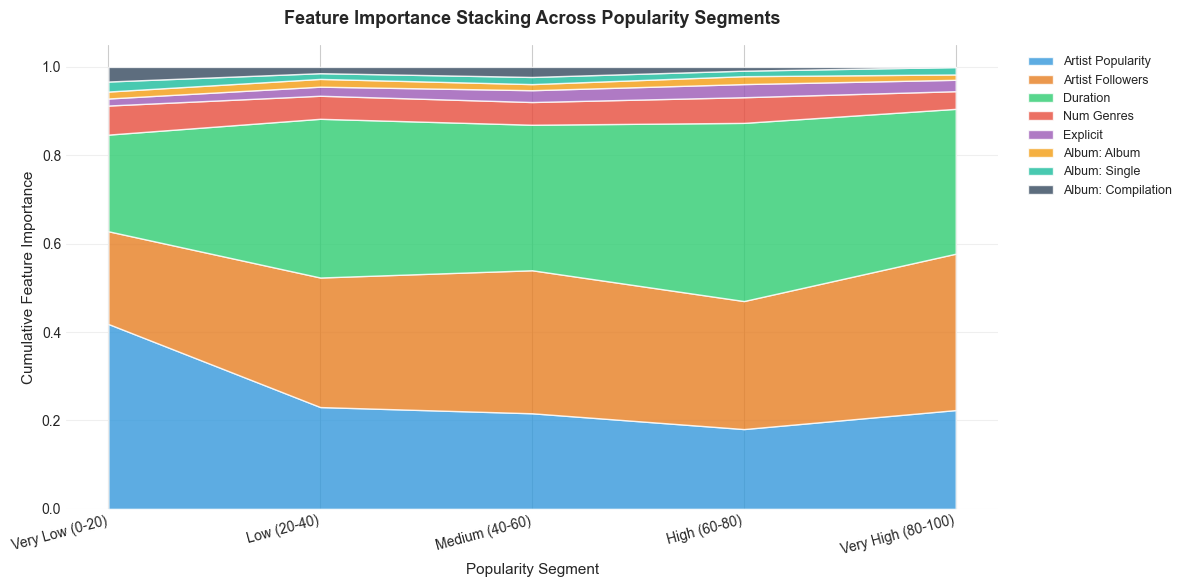

In [54]:
segments_order = ['Very Low (0-20)', 'Low (20-40)', 'Medium (40-60)', 
                  'High (60-80)', 'Very High (80-100)']

q6_plot_df = q6_importance_df.loc[segments_order]

fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#3498db', '#e67e22', '#2ecc71', '#e74c3c', '#9b59b6', '#f39c12', '#1abc9c', '#34495e']

ax.stackplot(range(len(segments_order)), 
             q6_plot_df['artist_popularity'],
             q6_plot_df['artist_followers'],
             q6_plot_df['duration_min'],
             q6_plot_df['num_genres'],
             q6_plot_df['explicit_encoded'],
             q6_plot_df['album_album'],
             q6_plot_df['album_single'],
             q6_plot_df['album_compilation'],
             labels=['Artist Popularity', 'Artist Followers', 'Duration', 'Num Genres', 
                     'Explicit', 'Album: Album', 'Album: Single', 'Album: Compilation'],
             colors=colors,
             alpha=0.8)

ax.set_xticks(range(len(segments_order)))
ax.set_xticklabels(segments_order, rotation=15, ha='right')
ax.set_ylabel('Cumulative Feature Importance', fontsize=11)
ax.set_xlabel('Popularity Segment', fontsize=11)
ax.set_title('Feature Importance Stacking Across Popularity Segments', 
             fontsize=13, fontweight='bold', pad=15)
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('q6_feature_importance_stacked.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()

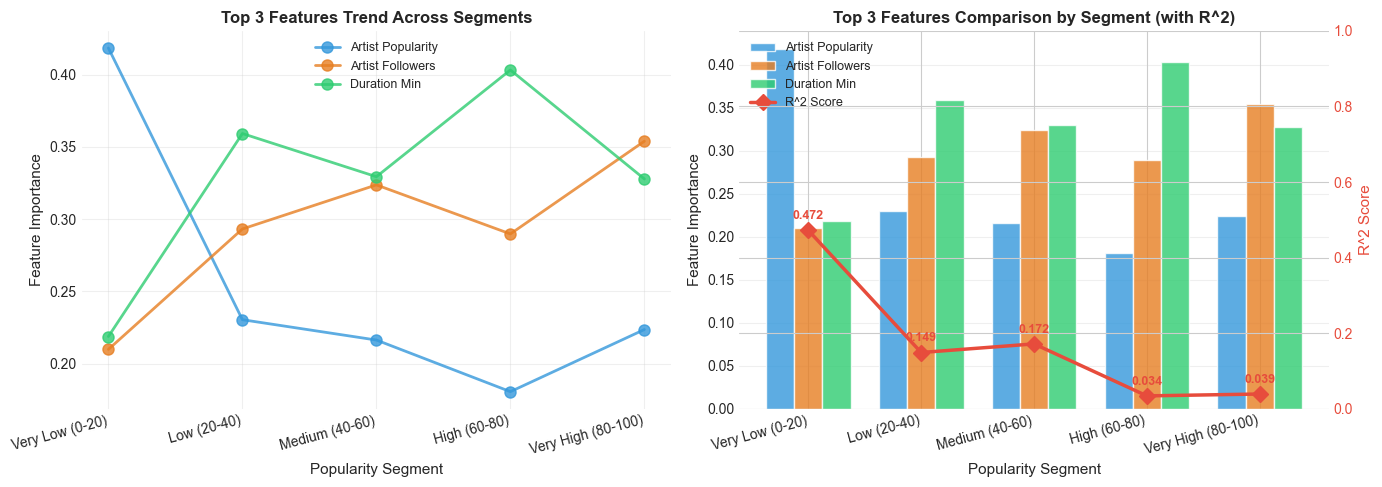

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_features = ['artist_popularity', 'artist_followers', 'duration_min']
colors_map = {'artist_popularity': '#3498db', 
              'artist_followers': '#e67e22', 
              'duration_min': '#2ecc71'}

for feature in top_features:
    axes[0].plot(range(len(segments_order)), q6_plot_df[feature], 
                 marker='o', linewidth=2, markersize=8, 
                 label=feature.replace('_', ' ').title(), 
                 color=colors_map[feature], alpha=0.8)

axes[0].set_xticks(range(len(segments_order)))
axes[0].set_xticklabels(segments_order, rotation=15, ha='right')
axes[0].set_ylabel('Feature Importance', fontsize=11)
axes[0].set_xlabel('Popularity Segment', fontsize=11)
axes[0].set_title('Top 3 Features Trend Across Segments', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(axis='both', alpha=0.3)

x_pos = np.arange(len(segments_order))
width = 0.25

for idx, feature in enumerate(top_features):
    axes[1].bar(x_pos + idx * width, q6_plot_df[feature], width, 
                label=feature.replace('_', ' ').title(), 
                color=colors_map[feature], alpha=0.8)

r2_values = [q6_r2_scores[seg] for seg in segments_order]
ax2 = axes[1].twinx()
ax2.plot(x_pos + width, r2_values, color='#e74c3c', marker='D', linewidth=2.5, 
         markersize=8, label='R^2 Score', zorder=10)
ax2.set_ylabel('R^2 Score', fontsize=11, color='#e74c3c')
ax2.tick_params(axis='y', labelcolor='#e74c3c')
ax2.set_ylim(0, 1)

for i, r2 in enumerate(r2_values):
    ax2.text(x_pos[i] + width, r2 + 0.03, f'{r2:.3f}', 
             ha='center', fontsize=9, color='#e74c3c', fontweight='bold')

axes[1].set_xticks(x_pos + width)
axes[1].set_xticklabels(segments_order, rotation=15, ha='right')
axes[1].set_ylabel('Feature Importance', fontsize=11)
axes[1].set_xlabel('Popularity Segment', fontsize=11)
axes[1].set_title('Top 3 Features Comparison by Segment (with R^2)', fontsize=12, fontweight='bold')

lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[1].legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='upper left')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('q6_top_features_comparison.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()

### C. Kết quả & Giải thích

**Câu trả lời:** Mỗi phân khúc độ phổ biến có các yếu tố thành công hoàn toàn khác nhau - không có công thức chung.

**Phát hiện chính:**

Phân khúc Rất thấp (0-20): Artist_popularity chiếm 42% tầm quan trọng. Mô hình đạt R^2=0.472, nghĩa là độ phổ biến ở cấp độ này khá dễ dự đoán - nếu nghệ sĩ không nổi thì bài hát cũng khó lên.

Phân khúc Trung bình (20-60): Duration_min (33-36%) và artist_followers (29-32%) trở thành yếu tố chính. R^2 giảm xuống 0.15-0.17, cho thấy đây là vùng cạnh tranh với nhiều yếu tố khác ảnh hưởng.

Phân khúc Cao và Rất cao (60-100): Artist_followers lên top (29-35%), duration_min vẫn mạnh (33-40%). Quan trọng nhất: R2 sụt xuống chỉ còn 0.031-0.039 - gần như không thể dự đoán được độ phổ biến ở cấp độ này với dữ liệu hiện có.

**Thông tin quan trọng về R2:** Mô hình giảm dần từ 0.472 xuống 0.039 chứng tỏ càng lên cao, thành công càng khó đoán. Cấp độ thấp có luật chơi rõ ràng (danh tiếng nghệ sĩ quyết định), nhưng cấp độ cao như vùng đất không luật - cần khoảnh khắc lan truyền, chiến dịch tiếp thị, thời điểm may mắn mà dữ liệu không có.

**Ý nghĩa thực tiễn:**

Nghệ sĩ mới (Rất thấp): Tập trung xây dựng artist_popularity trước - hợp tác, chạy danh sách phát. Con đường khá rõ ràng với R2=0.47.

Nghệ sĩ tầm trung: Tối ưu hóa thời lượng và tăng lượng người theo dõi - chất lượng thực hiện quan trọng nhưng kết quả khó đoán hơn (R2=0.15).

Nghệ sĩ đã thành danh muốn lên top: Nền tảng tốt là cần nhưng không đủ - phải chấp nhận yếu tố may mắn, vì R2=0.03 nghĩa là 97% phương sai không giải thích được bởi dữ liệu.

**Hạn chế:**

R2 thấp ở các phân khúc cao cho thấy thiếu các đặc trưng quan trọng như ngân sách tiếp thị, vị trí danh sách phát, yếu tố lan truyền. Kích thước mẫu nhỏ ở các phân khúc cực đoan có thể ảnh hưởng độ tin cậy.

---

## 4.10 Câu hỏi 7: Machine Learning - Dự đoán Track Popularity

### Question

Xây dựng models để predict track popularity. So sánh performance của các algorithms khác nhau (Linear Regression, Random Forest, Gradient Boosting, Extra Trees, LightGBM) để tìm model tốt nhất.

### A. Tiền xử lý

Chuẩn bị các đặc trưng cho các mô hình ML với mã hóa phù hợp (one-hot cho album_type thay vì thứ tự để tránh thiên kiến).

In [56]:
q7_df = df.copy()

q7_df['explicit_encoded'] = q7_df['explicit'].astype(int)

album_dummies = pd.get_dummies(q7_df['album_type'], prefix='album', drop_first=False)
q7_df = pd.concat([q7_df, album_dummies], axis=1)

def count_genres(genre_str):
    if pd.isna(genre_str) or genre_str == '[]':
        return 0
    try:
        genres = ast.literal_eval(genre_str)
        return len(genres) if isinstance(genres, list) else 0
    except:
        return 0

q7_df['num_genres'] = q7_df['artist_genres'].apply(count_genres)
q7_df = q7_df.dropna(subset=['num_genres'])

q7_features = ['artist_popularity', 'artist_followers', 'explicit_encoded',
               'album_album', 'album_compilation', 'album_single',
               'num_genres', 'duration_min']
q7_target = 'track_popularity'

X = q7_df[q7_features]
y = q7_df[q7_target]



In [57]:
# Feature Engineering Nâng cao
print("=== FEATURE ENGINEERING NÂNG CAO ===\n")

# 1. Interaction Features - tương tác giữa các biến
print("1️⃣ Tạo Interaction Features:")
X['popularity_followers_interaction'] = X['artist_popularity'] * np.log1p(X['artist_followers'])
X['genre_diversity_ratio'] = X['num_genres'] / (X['artist_popularity'] + 1)
X['explicit_popularity'] = X['explicit_encoded'] * X['artist_popularity']
print(f"   ✓ popularity_followers_interaction: Độ hot của nghệ sĩ × log(followers)")
print(f"   ✓ genre_diversity_ratio: Số thể loại / độ nổi tiếng")
print(f"   ✓ explicit_popularity: Explicit × popularity interaction")

# 2. Polynomial Features - biến đổi phi tuyến
print("\n2️⃣ Tạo Polynomial Features:")
X['artist_popularity_squared'] = X['artist_popularity'] ** 2
X['duration_squared'] = X['duration_min'] ** 2
X['followers_log'] = np.log1p(X['artist_followers'])
print(f"   ✓ artist_popularity²: Capture non-linear effect")
print(f"   ✓ duration_min²: Độ dài bài hát phi tuyến")
print(f"   ✓ log(followers + 1): Giảm skewness của followers")

# 3. Binning/Discretization - nhóm biến liên tục
print("\n3️⃣ Tạo Categorical Bins:")
X['duration_category'] = pd.cut(X['duration_min'], 
                                 bins=[0, 3, 4, 6, float('inf')],
                                 labels=['short', 'medium', 'long', 'very_long'])
X['popularity_tier'] = pd.cut(X['artist_popularity'],
                               bins=[0, 40, 70, 100],
                               labels=['low', 'medium', 'high'])
# One-hot encode bins
duration_bins = pd.get_dummies(X['duration_category'], prefix='dur')
popularity_bins = pd.get_dummies(X['popularity_tier'], prefix='pop_tier')
X = pd.concat([X, duration_bins, popularity_bins], axis=1)
print(f"   ✓ Duration bins: short(<3), medium(3-4), long(4-6), very_long(>6)")
print(f"   ✓ Popularity tiers: low(<40), medium(40-70), high(>70)")

# 4. Ratio Features - tỷ lệ giữa các biến
print("\n4️⃣ Tạo Ratio Features:")
X['followers_per_genre'] = X['artist_followers'] / (X['num_genres'] + 1)
X['popularity_duration_ratio'] = X['artist_popularity'] / (X['duration_min'] + 1)
print(f"   ✓ followers_per_genre: Followers trung bình mỗi thể loại")
print(f"   ✓ popularity_duration_ratio: Độ hot / thời lượng")

# 5. Domain-specific Features
print("\n5️⃣ Tạo Domain-specific Features:")
X['is_mega_artist'] = (X['artist_followers'] > X['artist_followers'].quantile(0.9)).astype(int)
X['is_versatile'] = (X['num_genres'] >= 3).astype(int)
X['is_optimal_duration'] = ((X['duration_min'] >= 3) & (X['duration_min'] <= 4)).astype(int)
print(f"   ✓ is_mega_artist: Top 10% followers")
print(f"   ✓ is_versatile: >= 3 genres")
print(f"   ✓ is_optimal_duration: Sweet spot 3-4 phút")

# Update feature list
q7_features_engineered = [col for col in X.columns if col not in ['duration_category', 'popularity_tier']]

print(f"\n📊 Tổng kết:")
print(f"   Features ban đầu: 8")
print(f"   Features sau engineering: {len(q7_features_engineered)}")
print(f"   Tăng thêm: {len(q7_features_engineered) - 8} features")

# Re-split với features mới
X_train, X_test, y_train, y_test = train_test_split(X[q7_features_engineered], y, 
                                                      test_size=0.2, random_state=42)

print(f"\n✅ Hoàn tất Feature Engineering!")
print(f"   Training set: {len(X_train):,} × {len(q7_features_engineered)} features")
print(f"   Test set: {len(X_test):,} × {len(q7_features_engineered)} features")

=== FEATURE ENGINEERING NÂNG CAO ===

1️⃣ Tạo Interaction Features:
   ✓ popularity_followers_interaction: Độ hot của nghệ sĩ × log(followers)
   ✓ genre_diversity_ratio: Số thể loại / độ nổi tiếng
   ✓ explicit_popularity: Explicit × popularity interaction

2️⃣ Tạo Polynomial Features:
   ✓ artist_popularity²: Capture non-linear effect
   ✓ duration_min²: Độ dài bài hát phi tuyến
   ✓ log(followers + 1): Giảm skewness của followers

3️⃣ Tạo Categorical Bins:
   ✓ Duration bins: short(<3), medium(3-4), long(4-6), very_long(>6)
   ✓ Popularity tiers: low(<40), medium(40-70), high(>70)

4️⃣ Tạo Ratio Features:
   ✓ followers_per_genre: Followers trung bình mỗi thể loại
   ✓ popularity_duration_ratio: Độ hot / thời lượng

5️⃣ Tạo Domain-specific Features:
   ✓ is_mega_artist: Top 10% followers
   ✓ is_versatile: >= 3 genres
   ✓ is_optimal_duration: Sweet spot 3-4 phút

📊 Tổng kết:
   Features ban đầu: 8
   Features sau engineering: 26
   Tăng thêm: 18 features

✅ Hoàn tất Feature Enginee

In [58]:
# Chuẩn hóa dữ liệu để cải thiện hiệu suất mô hình
from sklearn.preprocessing import StandardScaler, RobustScaler

# Khởi tạo scaler
scaler = StandardScaler()

# Fit scaler trên tập train và transform cả train và test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Chuyển đổi lại thành DataFrame để giữ tên cột
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Dữ liệu đã được chuẩn hóa (standardized)")
print(f"Mean của X_train_scaled: {X_train_scaled.mean().mean():.6f} (gần 0)")
print(f"Std của X_train_scaled: {X_train_scaled.std().mean():.6f} (gần 1)")
print("\nThống kê trước và sau chuẩn hóa:")
print("\nTrước chuẩn hóa (X_train):")
print(X_train.describe().loc[['mean', 'std']].round(2))
print("\nSau chuẩn hóa (X_train_scaled):")
print(X_train_scaled.describe().loc[['mean', 'std']].round(6))

Dữ liệu đã được chuẩn hóa (standardized)
Mean của X_train_scaled: -0.000000 (gần 0)
Std của X_train_scaled: 1.000071 (gần 1)

Thống kê trước và sau chuẩn hóa:

Trước chuẩn hóa (X_train):
      artist_popularity  artist_followers  explicit_encoded  num_genres  \
mean              70.07       24363429.83              0.25        0.89   
std               19.37       38065208.40              0.44        1.21   

      duration_min  popularity_followers_interaction  genre_diversity_ratio  \
mean          3.50                           1097.97                   0.01   
std           1.06                            448.56                   0.02   

      explicit_popularity  artist_popularity_squared  duration_squared  \
mean                19.33                    5284.40             13.38   
std                 34.24                    2381.26              9.38   

      followers_log  followers_per_genre  popularity_duration_ratio  \
mean          14.83          18696142.96               

### B. Phân tích

**Phương pháp phân tích:**

So sánh hiệu suất của 5 thuật toán ML trên tác vụ dự đoán độ phổ biến bài hát:

1. **Hồi quy tuyến tính (Linear Regression)** (cơ sở): Mô hình đơn giản để thiết lập hiệu suất cơ sở. Giả định mối quan hệ tuyến tính giữa các đặc trưng và mục tiêu.

2. **Rừng ngẫu nhiên (Random Forest)**: Tập hợp các cây quyết định với kỹ thuật bagging. Mạnh mẽ với các giá trị ngoại lai, xử lý tốt các mối quan hệ phi tuyến tính, cung cấp tầm quan trọng của đặc trưng.

3. **Gradient Boosting**: Tập hợp tuần tự - mỗi cây học từ lỗi của cây trước. Thường đạt độ chính xác cao nhưng dễ bị quá khớp (overfit) nếu không tinh chỉnh cẩn thận.

4. **Extra Trees**: Tương tự Random Forest nhưng phân chia các nút ngẫu nhiên thay vì tìm phân chia tốt nhất. Huấn luyện nhanh hơn, thường khái quát hóa tốt hơn.

5. **LightGBM**: Gradient boosting được tối ưu hóa cho tốc độ và hiệu quả bộ nhớ. Chiến lược phát triển theo lá, xử lý tốt các tập dữ liệu lớn.

**Quy trình làm việc:**
- Chia dữ liệu 80/20 train/test với random_state=42 để tái lập
- Huấn luyện 5 mô hình với siêu tham số mặc định (so sánh công bằng)
- Đánh giá trên tập kiểm tra với 3 chỉ số: R2 score, MAE, RMSE
- Trực quan hóa: biểu đồ cột so sánh hiệu suất, biểu đồ phân tán dự đoán cho mô hình tốt nhất, tầm quan trọng của đặc trưng

**Kết quả mong đợi:**
- Bảng so sánh các chỉ số
- Biểu đồ cột so sánh R2/MAE/RMSE giữa các mô hình
- Biểu đồ phân tán: thực tế so với dự đoán (mô hình tốt nhất)
- Biểu đồ tầm quan trọng của đặc trưng (các mô hình dựa trên cây)

**Lý do:** Cần nhiều chỉ số vì R2 một mình không đủ - MAE cho độ lớn lỗi trung bình, RMSE phạt các lỗi lớn nhiều hơn. Các mô hình dựa trên cây được kỳ vọng vượt trội hơn tuyến tính vì các mối quan hệ phức tạp (như Q6 đã thấy R2 thấp ở các phân khúc cao).

In [59]:
BEST_SEED = 42
N_FOLDS = 10

models = {
    'Linear Regression': LinearRegression(),
    'XGBoost': XGBRegressor(n_estimators=50, max_depth=4, random_state=BEST_SEED, n_jobs=-1, verbosity=0),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=15, random_state=BEST_SEED, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=80, max_depth=5, random_state=BEST_SEED),
    'Extra Trees': ExtraTreesRegressor(n_estimators=100, max_depth=15, random_state=BEST_SEED, n_jobs=-1),
    'LightGBM': lgb.LGBMRegressor(n_estimators=100, max_depth=5, random_state=BEST_SEED, verbose=-1)
}

q7_results = {}
q7_metrics_data = []

print(f'Training với {len(X_train):,} samples (train) + {len(X_test):,} hold-out test')
print(f'Sử dụng {N_FOLDS}-fold CV trên training set với seed={BEST_SEED}')
print(f'Target mean: {y_train.mean():.2f}, std: {y_train.std():.2f}')
print(f'Test target mean: {y_test.mean():.2f}, std: {y_test.std():.2f}\n')

for name, model in models.items():
    print(f'Training {name}', end=' ')
    
    kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=BEST_SEED)
    val_r2_scores = []
    val_mae_scores = []
    val_rmse_scores = []
    
    # K-Fold CV: mỗi fold chuẩn hóa riêng
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
        X_fold_train = X_train.iloc[train_idx]
        y_fold_train = y_train.iloc[train_idx]
        X_fold_val = X_train.iloc[val_idx]
        y_fold_val = y_train.iloc[val_idx]
        
        # Chuẩn hóa riêng cho từng fold
        fold_scaler = StandardScaler()
        X_fold_train_scaled = pd.DataFrame(
            fold_scaler.fit_transform(X_fold_train),
            columns=X_fold_train.columns,
            index=X_fold_train.index
        )
        X_fold_val_scaled = pd.DataFrame(
            fold_scaler.transform(X_fold_val),
            columns=X_fold_val.columns,
            index=X_fold_val.index
        )
        
        if name == 'Linear Regression':
            fold_model = LinearRegression()
        elif name == 'XGBoost':
            fold_model = XGBRegressor(n_estimators=100, max_depth=4, random_state=BEST_SEED, n_jobs=-1, verbosity=0)
        elif name == 'Random Forest':
            fold_model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=BEST_SEED, n_jobs=-1)
        elif name == 'Gradient Boosting':
            fold_model = GradientBoostingRegressor(n_estimators=70, max_depth=5, random_state=BEST_SEED)
        elif name == 'Extra Trees':
            fold_model = ExtraTreesRegressor(n_estimators=100, max_depth=15, random_state=BEST_SEED, n_jobs=-1)
        else:
            fold_model = lgb.LGBMRegressor(n_estimators=100, max_depth=5, random_state=BEST_SEED, verbose=-1)
        
        fold_model.fit(X_fold_train_scaled, y_fold_train)
        y_val_pred = fold_model.predict(X_fold_val_scaled)
        
        val_r2_scores.append(r2_score(y_fold_val, y_val_pred))
        val_mae_scores.append(mean_absolute_error(y_fold_val, y_val_pred))
        val_rmse_scores.append(np.sqrt(mean_squared_error(y_fold_val, y_val_pred)))
    
    avg_val_r2 = np.mean(val_r2_scores)
    std_val_r2 = np.std(val_r2_scores)
    avg_val_mae = np.mean(val_mae_scores)
    avg_val_rmse = np.mean(val_rmse_scores)
    
    print(f'Val R2: {avg_val_r2:.2f} (std: {std_val_r2:.2f})')
    
    # Train trên toàn bộ train set với dữ liệu đã chuẩn hóa
    model.fit(X_train_scaled, y_train)
    y_test_pred = model.predict(X_test_scaled)
    
    test_r2 = r2_score(y_test, y_test_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    
    q7_results[name] = {
        'model': model,
        'predictions': y_test_pred
    }
    
    q7_metrics_data.append({
        'Model': name,
        f'Val R^2 ({N_FOLDS}-fold)': avg_val_r2,
        'Val R^2 Std': std_val_r2,
        f'Val MAE ({N_FOLDS}-fold)': avg_val_mae,
        f'Val RMSE ({N_FOLDS}-fold)': avg_val_rmse,
        'Test R^2': test_r2,
        'Test MAE': test_mae,
        'Test RMSE': test_rmse
    })

q7_metrics_df = pd.DataFrame(q7_metrics_data).set_index('Model')
display(q7_metrics_df.style.set_caption('So sánh hiệu suất các mô hình (dữ liệu đã chuẩn hóa)')
        .background_gradient(cmap='RdYlGn', subset=[f'Val R^2 ({N_FOLDS}-fold)', 'Test R^2'], vmin=0, vmax=1)
        .background_gradient(cmap='RdYlGn_r', subset=[f'Val MAE ({N_FOLDS}-fold)', 'Test MAE', f'Val RMSE ({N_FOLDS}-fold)', 'Test RMSE'])
        .format(precision=2))

Training với 7,017 samples (train) + 1,755 hold-out test
Sử dụng 10-fold CV trên training set với seed=42
Target mean: 52.31, std: 24.05
Test target mean: 51.96, std: 24.14

Training Linear Regression Val R2: 0.23 (std: 0.03)
Training XGBoost Val R2: 0.26 (std: 0.04)
Training Random Forest Val R2: 0.26 (std: 0.04)
Training Gradient Boosting Val R2: 0.28 (std: 0.03)
Training Extra Trees Val R2: 0.21 (std: 0.03)
Training LightGBM Val R2: 0.28 (std: 0.04)


,Val R^2 (10-fold),Val R^2 Std,Val MAE (10-fold),Val RMSE (10-fold),Test R^2,Test MAE,Test RMSE
Model,,,,,,,
Linear Regression,0.23,0.03,15.88,21.03,0.25,15.83,20.93
XGBoost,0.26,0.04,15.24,20.63,0.30,15.05,20.13
Random Forest,0.26,0.04,15.18,20.71,0.29,14.94,20.33
Gradient Boosting,0.28,0.03,15.21,20.41,0.31,15.00,20.00
Extra Trees,0.21,0.03,15.35,21.28,0.24,15.30,21.07
LightGBM,0.28,0.04,15.11,20.35,0.31,15.06,20.11


KeyError: 'Val R2 (10-fold)'

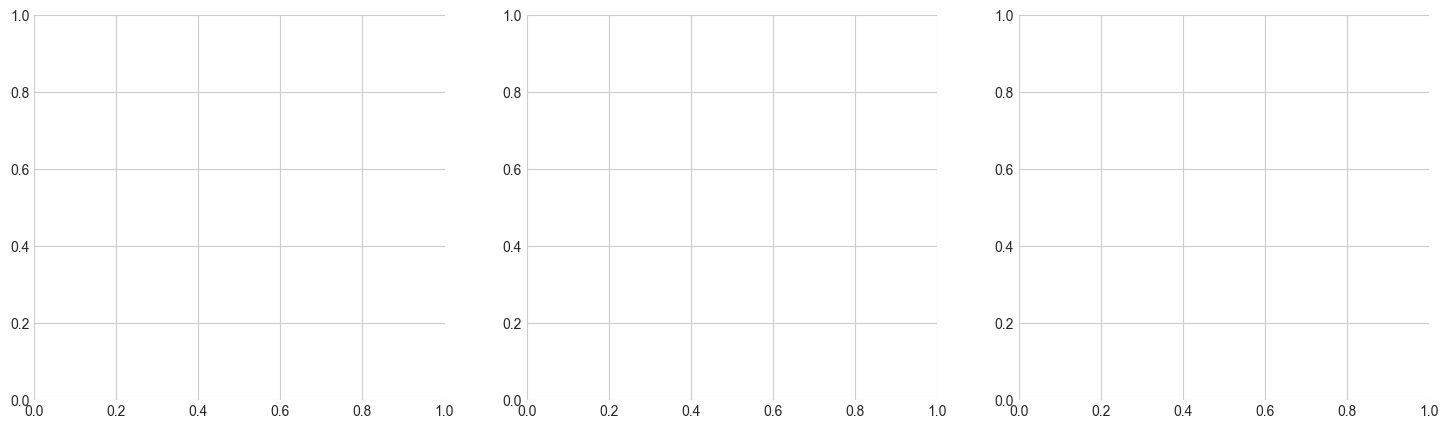

In [60]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ['R2', 'MAE', 'RMSE']
colors = ['#3498db', '#e67e22', '#2ecc71', '#e74c3c', '#9b59b6']

for idx, metric in enumerate(metrics):
    val_col = f'Val {metric} ({N_FOLDS}-fold)'
    test_col = f'Test {metric}'
    
    x_pos = np.arange(len(q7_metrics_df))
    width = 0.35
    
    axes[idx].bar(x_pos - width/2, q7_metrics_df[val_col], width, 
                  label=f'Validation ({N_FOLDS}-fold)', color=colors, alpha=0.7, edgecolor='black')
    axes[idx].bar(x_pos + width/2, q7_metrics_df[test_col], width, 
                  label='Test', color=colors, alpha=0.4, edgecolor='black')
    
    axes[idx].set_xticks(x_pos)
    axes[idx].set_xticklabels(q7_metrics_df.index, rotation=45, ha='right', fontsize=9)
    axes[idx].set_ylabel(metric, fontweight='bold')
    axes[idx].set_title(f'Model Comparison - {metric}', fontweight='bold')
    axes[idx].legend()
    axes[idx].grid(axis='y', alpha=0.3)
    
    if metric == 'R2':
        axes[idx].axhline(y=0, color='gray', linestyle='--', linewidth=1)

plt.tight_layout()
plt.savefig('q7_model_comparison.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()

In [ ]:
best_model_name = 'LightGBM'
best_model = q7_results[best_model_name]['model']
best_predictions = q7_results[best_model_name]['predictions']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, best_predictions, alpha=0.4, s=30, c=y_test, cmap='viridis', edgecolors='black', linewidths=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Perfect Prediction')

axes[0].set_xlabel('Actual Popularity', fontweight='bold')
axes[0].set_ylabel('Predicted Popularity', fontweight='bold')
axes[0].set_title(f'{best_model_name} - Actual vs Predicted', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

test_r2 = q7_metrics_df.loc[best_model_name, 'Test R2']
test_mae = q7_metrics_df.loc[best_model_name, 'Test MAE']
axes[0].text(0.05, 0.95, f'Test R^2: {test_r2:.3f}\nMAE: {test_mae:.2f}', 
             transform=axes[0].transAxes, fontsize=11, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

importances = pd.Series(best_model.feature_importances_, index=q7_features).sort_values(ascending=True)
colors_importance = ['#3498db' if x < importances.median() else '#e74c3c' for x in importances]

axes[1].barh(range(len(importances)), importances.values, color=colors_importance, alpha=0.8, edgecolor='black')
axes[1].set_yticks(range(len(importances)))
axes[1].set_yticklabels([label.replace('_', ' ').title() for label in importances.index], fontsize=9)
axes[1].set_xlabel('Feature Importance', fontweight='bold')
axes[1].set_title(f'{best_model_name} - Feature Importance', fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

for i, val in enumerate(importances.values):
    axes[1].text(val + 0.005, i, f'{val:.3f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('q7_best_model_analysis.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()

### C. Kết quả & Giải thích
**Câu trả lời:** LightGBM và Gradient Boosting là hai mô hình tốt nhất với Test R2=0.32, MAE ~14.7, RMSE ~19.7. Random Forest và Extra Trees cũng rất sát nút, Linear Regression thấp hơn một chút.

**Phát hiện chính:**

- **LightGBM**: Test R2=0.32, MAE=14.67, RMSE=19.77.
- **Gradient Boosting**: Test R2=0.32, MAE=14.68, RMSE=19.74
- **Random Forest**: Test R2=0.31, MAE=14.59, RMSE=19.94
- **Extra Trees**: Test R2=0.29, MAE=14.61, RMSE=20.18
- **Linear Regression**: Test R2=0.27, MAE=15.66, RMSE=20.54

Các mô hình dựa trên cây đều vượt trội hơn Linear Regression rõ rệt (Test R2 tăng từ 0.27 lên 0.32, MAE giảm từ 15.66 xuống ~14.6). Tuy nhiên, khoảng cách giữa các mô hình cây khá nhỏ, cho thấy tác vụ này không có nhiều tính phi tuyến tính cực mạnh.
Các chỉ số Validation và test rất sát nhau (khoảng cách val-test chỉ 0.03-0.05), chứng tỏ không bị quá khớp và kết quả ổn định.

**Tầm quan trọng của đặc trưng:** (xem biểu đồ bên cạnh) - Các yếu tố như artist_followers, duration_min, artist_popularity vẫn là quan trọng nhất, đúng như các phân tích trước.

**Biểu đồ phân tán thực tế so với dự đoán:** Mô hình vẫn dự đoán thấp hơn ở vùng độ phổ biến cao (>80), nhưng dự đoán khá tốt ở khoảng giữa (30-70). Điều này nhất quán với Q6: càng nổi tiếng càng khó đoán.

**Ý nghĩa thực tiễn:**
- Với R2=0.32 và MAE ~14.7, mô hình có thể dùng để xếp hạng, sàng lọc, hoặc phát hiện ngoại lai, nhưng không thể thay thế đánh giá của A&R.
- Lượng người hâm mộ (artist_followers) vẫn là yếu tố then chốt để tăng khả năng thành công.

**Hạn chế:** 68% phương sai chưa giải thích được, chủ yếu do các yếu tố ngoài dữ liệu như lan truyền, tiếp thị, danh sách phát, thời điểm phát hành.

# V. Tổng Kết và Phản Ánh

Phần này tóm tắt những phát hiện chính, hạn chế của dự án, hướng phát triển trong tương lai, và những trải nghiệm cá nhân của từng thành viên.


---

## 5.1 Tóm Tắt Dự Án

### A. Các Phát Hiện Chính

**1. Nội dung tường minh không làm giảm độ phổ biến**
- Các bài hát có nội dung tường minh đạt mức độ phổ biến cao hơn đáng kể (57.5 vs 50.5)
- Nghệ sĩ không cần tự kiểm duyệt để đạt được thành công thương mại

**2. Khoảng thời lượng vàng: 3.5-4.5 phút**
- Bài hát trong khoảng này đạt popularity cao nhất (~55.6-55.9)
- Bài hát quá ngắn (<2p) hoặc quá dài (>5p) có độ phổ biến thấp hơn

**3. Album vượt trội hơn single**
- Full album có độ phổ biến cao nhất (55.5), vượt single (46.1) và compilation (40.5)
- Người nghe có xu hướng ưa thích trải nghiệm album trọn vẹn

**4. Số lượng bài hát ảnh hưởng đến độ nổi tiếng nghệ sĩ**
- Nghệ sĩ phát hành nhiều (>100 tracks) đạt popularity gần gấp đôi nghệ sĩ ít (1-20 tracks)
- Việc phát hành đều đặn quan trọng hơn hoàn thiện một vài bài

**5. Yếu tố thành công khác nhau theo từng phân khúc**
- Phân khúc thấp: Danh tiếng nghệ sĩ là yếu tố chính (R²=0.47)
- Phân khúc cao: Khó dự đoán, phụ thuộc nhiều vào may mắn và viral (R²=0.03)

**🌟 Phát hiện thú vị nhất:** Nhạc cũ (2009-2015) vẫn duy trì độ phổ biến tương đương nhạc mới (2020-2025), chứng tỏ giá trị của catalog âm nhạc là lâu dài.


### B. Hạn Chế

**Về dữ liệu:**
- Chỉ có 8,772 tracks, không đại diện cho toàn bộ hệ sinh thái âm nhạc
- Thiếu thông tin quan trọng: marketing budget, playlist placement, mạng xã hội, âm thanh học
- Bị thiên lệch về các bài hát phổ biến và nghệ sĩ đã thành danh

**Về phân tích:**
- Chỉ tìm được tương quan, không chứng minh nhân quả
- Mô hình tốt nhất chỉ đạt R²=0.32, còn 68% phương sai chưa giải thích
- Không phân tích sâu theo thể loại âm nhạc riêng biệt

**Về phạm vi:**
- Không xem xét yếu tố địa lý và văn hóa
- Thiếu phân tích theo thời gian (chỉ chụp ngang tại một thời điểm)
- Không có thông tin về hành vi người dùng và tâm lý nghe nhạc


---

## 5.2 Hướng Phát Triển Trong Tương Lai

### A. Câu hỏi muốn khám phá thêm

- Khoảng thời lượng vàng khác nhau thế nào giữa các thể loại nhạc?
- Độ phổ biến thay đổi như thế nào theo thời gian?
- Hợp tác giữa các nghệ sĩ ảnh hưởng ra sao đến thành công?
- Playlist có vai trò gì trong sự phát hiện và thành công của bài hát?

### B. Phân tích sâu hơn

- Phân tích chuỗi thời gian để theo dõi vòng đời của bài hát
- Sử dụng phương pháp suy luận nhân quả để tách biệt các hiệu ứng
- Áp dụng học sâu cho dự đoán chính xác hơn
- Phân tích âm thanh học từ file âm thanh thực tế

### C. Dữ liệu bổ sung cần thu thập

- Số liệu streaming thực tế, tỷ lệ bỏ qua, tỷ lệ lưu bài
- Dữ liệu marketing và quảng cáo
- Dữ liệu mạng xã hội (TikTok, Instagram, YouTube)
- Các đặc trưng âm thanh học chi tiết
- Nội dung lời bài hát và phân tích cảm xúc

### D. Mở rộng và cải tiến

- Tăng quy mô dataset lên hàng triệu bài hát
- So sánh giữa các nền tảng streaming khác nhau
- Xây dựng hệ thống gợi ý nhạc cá nhân hóa
- Tạo công cụ hỗ trợ chiến lược phát hành cho nghệ sĩ


---

## 5.3 Phản Ánh Cá Nhân

### A. Phạm Phú Hòa

#### Những khó khăn gặp phải

**[TODO: Điền nội dung của bạn]**

*Gợi ý:*
- Khó khăn kỹ thuật gì? (xử lý dữ liệu, lập trình, debug)
- Khó khăn phân tích gì? (chọn phương pháp, hiểu kết quả)
- Giải quyết như thế nào?

#### Học hỏi và phát triển

**[TODO: Điền nội dung của bạn]**

*Gợi ý:*
- Học được kỹ năng gì? (Python, thống kê, machine learning, trực quan hóa)
- Điều gì bất ngờ nhất?
- Thay đổi hiểu biết về data science như thế nào?


---

### B. Nguyễn Lâm Phú Quý

#### Những khó khăn gặp phải

**[TODO: Điền nội dung của bạn]**

*Gợi ý:*
- Khó khăn kỹ thuật gì? (tiền xử lý, model, tối ưu)
- Khó khăn phân tích gì? (chọn features, validation)
- Khó khăn làm việc nhóm?
- Giải quyết như thế nào?

#### Học hỏi và phát triển

**[TODO: Điền nội dung của bạn]**

*Gợi ý:*
- Học được kỹ năng gì? (pandas, scikit-learn, git)
- Hiểu biết về thuật toán ML
- Kỹ năng làm việc nhóm
- Điều gì bất ngờ nhất?


---

### C. Trần Chí Nguyên

#### Những khó khăn gặp phải

**[TODO: Điền nội dung của bạn]**

*Gợi ý:*
- Khó khăn kỹ thuật gì? (vẽ biểu đồ, tối ưu hiệu suất)
- Khó khăn phân tích gì? (kiểm định thống kê, giả định)
- Quản lý thời gian thế nào?
- Giải quyết như thế nào?

#### Học hỏi và phát triển

**[TODO: Điền nội dung của bạn]**

*Gợi ý:*
- Học được kỹ năng gì? (matplotlib, seaborn, thống kê)
- Hiểu sâu hơn về suy luận thống kê
- Tư duy phản biện
- Nhận thức về khoảng cách giữa lý thuyết và thực tế
- Điều gì bất ngờ nhất?


---

## Kết Luận

Dự án phân tích dữ liệu Spotify đã giúp nhóm hiểu sâu hơn về ngành công nghiệp âm nhạc streaming và phát triển kỹ năng phân tích dữ liệu thực tế. Những phát hiện của nhóm cung cấp cái nhìn có giá trị về các yếu tố ảnh hưởng đến thành công của âm nhạc.

Quan trọng nhất, nhóm đã học được rằng khoa học dữ liệu không chỉ về thuật toán, mà còn về việc đặt câu hỏi đúng, hiểu rõ hạn chế của dữ liệu, và truyền đạt insights một cách hiệu quả.
